# IMC Prosperity 4 — Research Notebook v2
### Multi-Round · Multi-Day · Dynamic Regime Detection

Based on Frankfurt Hedgehogs' methodology (2nd globally, Prosperity 3).

**How to use this notebook each round:**
1. Drop new CSV files into the same folder
2. Update `ROUND_REGISTRY` in Section 1 with the new round number and day list
3. Re-run all cells — every section auto-adapts to all registered rounds/days/products

---
**Sections:**
1. [Setup & Multi-Round Data Registry](#1-setup)
2. [Product Catalogue — What's new this round?](#2-catalogue)
3. [Wall Mid & Fair Value Computation](#3-wallmid)
4. [Cross-Day Regime Detection](#4-regime) ← *New: detects structural changes between days*
5. [Spread & Edge Analysis](#5-spread)
6. [True Price Identification (Fixed vs Drifting)](#6-trueprice)
7. [Orderbook Visualisation](#7-orderbook)
8. [Trade Classification & Edge Distribution](#8-trades)
9. [Informed Trader Detection](#9-informed)
10. [Return Structure & Autocorrelation](#10-acf)
11. [Bot Behavior Profiling](#11-bots)
12. [Market Making Backtest & Grid Search](#12-backtest)
13. [ETF Basket Spread Template (Round 2+)](#13-etf)
14. [Options / Black-Scholes Template (Round 3+)](#14-options)
15. [Round Summary & Strategy Card](#15-summary)


<a id='1-setup'></a>
## 1. Setup & Multi-Round Data Registry

**To add a new round:** append an entry to `ROUND_REGISTRY` and drop the CSVs in the same folder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (16, 5), 'axes.grid': True,
    'grid.alpha': 0.25, 'font.size': 11, 'axes.spines.top': False,
    'axes.spines.right': False,
})
COLORS = {
    'bid': '#4477AA', 'ask': '#EE6677', 'mid': '#228833',
    'wall_mid': '#000000', 'trade': '#CCBB44', 'signal_buy': '#22AA44',
    'signal_sell': '#AA2244', 'pnl': '#3366AA', 'position': '#AA6633',
}
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  ROUND REGISTRY — Update this block each round                          ║
# ║  Format: {round_num: [list_of_days]}                                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
ROUND_REGISTRY = {
    0: [-2, -1],   # Tutorial round: days -2 and -1
    # 1: [-2, -1], # ← Uncomment and fill when Round 1 data arrives
    # 2: [-2, -1],
    # 3: [-2, -1],
}

# ── Active round (change this to switch analysis focus) ─────────────────────
ACTIVE_ROUND = 0

# ETF basket compositions (fill when Round 2+ products appear)
BASKET_DEFINITIONS = {
    # 'PICNIC_BASKET1': {'CROISSANTS': 6, 'JAMS': 3, 'DJEMBES': 1},
    # 'PICNIC_BASKET2': {'CROISSANTS': 4, 'JAMS': 2},
}

# Position limits per product (fill from wiki each round)
POSITION_LIMITS = {
    'EMERALDS': 80,
    'TOMATOES': 80,
    # Add new products here
}
DEFAULT_POSITION_LIMIT = 80

print(f'Active round: {ACTIVE_ROUND}')
print(f'Registered rounds: {list(ROUND_REGISTRY.keys())}')

Active round: 0
Registered rounds: [0]


In [3]:
# ── Data Loader ──────────────────────────────────────────────────────────────
def load_all_data(registry):
    """
    Load all prices and trades CSVs defined in registry.
    Returns:
        prices_all : DataFrame with columns [day, round, product, timestamp, ...]
        trades_all : DataFrame with columns [day, round, symbol, timestamp, ...]
    """
    all_prices, all_trades = [], []
    for rnd, days in registry.items():
        for day in days:
            p_file = f'../data/TUTORIAL_ROUND_1/prices_round_{rnd}_day_{day}.csv'
            t_file = f'../data/TUTORIAL_ROUND_1/trades_round_{rnd}_day_{day}.csv'
            try:
                p = pd.read_csv(p_file, sep=';')
                p.columns = p.columns.str.strip()
                p['round'] = rnd
                p['day']   = day
                all_prices.append(p)
                print(f'  ✓ {p_file}  ({len(p):,} rows, products: {sorted(p["product"].unique().tolist())})')
            except FileNotFoundError:
                print(f'  ✗ {p_file} NOT FOUND — skipping')
            try:
                t = pd.read_csv(t_file, sep=';')
                t.columns = t.columns.str.strip()
                t['round'] = rnd
                t['day']   = day
                all_trades.append(t)
                print(f'  ✓ {t_file}  ({len(t):,} rows)')
            except FileNotFoundError:
                print(f'  ✗ {t_file} NOT FOUND — skipping')

    prices_all = pd.concat(all_prices, ignore_index=True) if all_prices else pd.DataFrame()
    trades_all = pd.concat(all_trades, ignore_index=True) if all_trades else pd.DataFrame()
    return prices_all, trades_all


print('Loading data...')
prices_all, trades_all = load_all_data(ROUND_REGISTRY)

# ── Convenience accessors ────────────────────────────────────────────────────
# Active round data
prices_rnd = prices_all[prices_all['round'] == ACTIVE_ROUND].copy()
trades_rnd = trades_all[trades_all['round'] == ACTIVE_ROUND].copy()

PRODUCTS = sorted(prices_rnd['product'].unique().tolist())
DAYS     = sorted(prices_rnd['day'].unique().tolist())

# Dict keyed by (product, day)
prices = {(p, d): prices_rnd[(prices_rnd['product']==p) & (prices_rnd['day']==d)].copy().reset_index(drop=True)
          for p in PRODUCTS for d in DAYS}
trades = {(p, d): trades_rnd[(trades_rnd['symbol']==p) & (trades_rnd['day']==d)].copy().reset_index(drop=True)
          for p in PRODUCTS for d in DAYS}

# Also keep per-product combined across all days (for cross-day analysis)
prices_prod = {p: prices_rnd[prices_rnd['product']==p].copy().reset_index(drop=True) for p in PRODUCTS}
trades_prod = {p: trades_rnd[trades_rnd['symbol']==p].copy().reset_index(drop=True) for p in PRODUCTS}

print(f'\nRound {ACTIVE_ROUND} | Products: {PRODUCTS} | Days: {DAYS}')

Loading data...
  ✓ ../data/TUTORIAL_ROUND_1/prices_round_0_day_-2.csv  (20,000 rows, products: ['EMERALDS', 'TOMATOES'])
  ✓ ../data/TUTORIAL_ROUND_1/trades_round_0_day_-2.csv  (588 rows)
  ✓ ../data/TUTORIAL_ROUND_1/prices_round_0_day_-1.csv  (20,000 rows, products: ['EMERALDS', 'TOMATOES'])
  ✓ ../data/TUTORIAL_ROUND_1/trades_round_0_day_-1.csv  (631 rows)

Round 0 | Products: ['EMERALDS', 'TOMATOES'] | Days: [-2, -1]


<a id='2-catalogue'></a>
## 2. Product Catalogue — What's New This Round?

In [4]:
# Build product catalogue across all rounds
catalogue = {}
for rnd in sorted(ROUND_REGISTRY.keys()):
    prods = sorted(prices_all[prices_all['round']==rnd]['product'].unique().tolist())
    catalogue[rnd] = set(prods)

print('Product Catalogue by Round')
print('=' * 55)
all_seen = set()
for rnd, prods in sorted(catalogue.items()):
    new = prods - all_seen
    print(f'  Round {rnd}:  {sorted(prods)}')
    if new:
        print(f'           🆕 NEW: {sorted(new)}')
    all_seen |= prods

print()
print('Active round product stats:')
print(f'{"Product":<20} {"Days":<12} {"Price rows":<14} {"Trade rows"}')
print('-' * 55)
for p in PRODUCTS:
    pr = sum(len(prices[(p,d)]) for d in DAYS)
    tr = sum(len(trades[(p,d)]) for d in DAYS)
    print(f'{p:<20} {str(DAYS):<12} {pr:<14} {tr}')

Product Catalogue by Round
  Round 0:  ['EMERALDS', 'TOMATOES']
           🆕 NEW: ['EMERALDS', 'TOMATOES']

Active round product stats:
Product              Days         Price rows     Trade rows
-------------------------------------------------------
EMERALDS             [-2, -1]     20000          399
TOMATOES             [-2, -1]     20000          820


<a id='3-wallmid'></a>
## 3. Wall Mid & Fair Value Computation

**Wall Mid** = midpoint between the bid/ask level with the *largest volume* (the liquidity "wall").  
This is Frankfurt Hedgehogs' preferred fair-value proxy — better than simple mid because it anchors to where the market has the most depth.

In [5]:
def compute_wall_mid(df):
    """Vectorised Wall Mid computation."""
    result = pd.Series(index=df.index, dtype=float)
    for i in [1, 2, 3]:
        bp, bv = f'bid_price_{i}', f'bid_volume_{i}'
        ap, av = f'ask_price_{i}', f'ask_volume_{i}'
        for col in [bp, bv, ap, av]:
            if col not in df.columns:
                df[col] = np.nan

    # Stack bid/ask levels, pick max-volume for each side
    bid_prices  = df[['bid_price_1','bid_price_2','bid_price_3']].values
    bid_vols    = df[['bid_volume_1','bid_volume_2','bid_volume_3']].values
    ask_prices  = df[['ask_price_1','ask_price_2','ask_price_3']].values
    ask_vols    = df[['ask_volume_1','ask_volume_2','ask_volume_3']].values

    # Fill NaN volumes with -1 so argmax ignores them
    bid_vols_f = np.where(np.isnan(bid_vols), -1, bid_vols)
    ask_vols_f = np.where(np.isnan(ask_vols), -1, ask_vols)

    bid_wall_idx = np.argmax(bid_vols_f, axis=1)
    ask_wall_idx = np.argmax(ask_vols_f, axis=1)

    wall_bid = bid_prices[np.arange(len(df)), bid_wall_idx]
    wall_ask = ask_prices[np.arange(len(df)), ask_wall_idx]

    wm = np.where(
        (~np.isnan(wall_bid)) & (~np.isnan(wall_ask)),
        (wall_bid + wall_ask) / 2,
        df['mid_price'].values
    )
    return pd.Series(wm, index=df.index)


# Apply to every (product, day) slice
for key in prices:
    prices[key]['wall_mid'] = compute_wall_mid(prices[key])
    prices[key]['spread_L1'] = prices[key]['ask_price_1'] - prices[key]['bid_price_1']

# Also apply to combined per-product DataFrames
for p in PRODUCTS:
    prices_prod[p]['wall_mid'] = compute_wall_mid(prices_prod[p])
    prices_prod[p]['spread_L1'] = prices_prod[p]['ask_price_1'] - prices_prod[p]['bid_price_1']

print('Wall Mid computed for all products/days ✓')
print()
for p in PRODUCTS:
    for d in DAYS:
        df = prices[(p,d)]
        diff = df['wall_mid'] - df['mid_price']
        print(f'{p} day={d:3d}: wall_mid offset → mean={diff.mean():.4f}, std={diff.std():.4f}')

Wall Mid computed for all products/days ✓

EMERALDS day= -2: wall_mid offset → mean=0.0028, std=0.7300
EMERALDS day= -1: wall_mid offset → mean=0.0020, std=0.7167
TOMATOES day= -2: wall_mid offset → mean=0.0241, std=0.9410
TOMATOES day= -1: wall_mid offset → mean=0.0197, std=0.9441


<a id='4-regime'></a>
## 4. Cross-Day Regime Detection

Key question every round: **Did anything change between days?**  
We test for shifts in: mean price · volatility · spread · autocorrelation · trade intensity.

In [6]:
def regime_stats(product, day):
    """Compute a dict of key regime statistics for one (product, day)."""
    df  = prices[(product, day)]
    tr  = trades[(product, day)]
    mid = df['mid_price']
    ret = mid.diff().dropna()

    adf_p = adfuller(mid.dropna(), maxlag=10, autolag='AIC')[1]

    return {
        'product': product, 'day': day,
        'mid_mean':       round(mid.mean(), 3),
        'mid_std':        round(mid.std(),  4),
        'mid_min':        mid.min(),
        'mid_max':        mid.max(),
        'spread_mean':    round(df['spread_L1'].mean(), 3),
        'spread_std':     round(df['spread_L1'].std(),  4),
        'ret_std':        round(ret.std(),   4),
        'lag1_acf':       round(ret.autocorr(1), 4),
        'lag2_acf':       round(ret.autocorr(2), 4),
        'adf_pval':       round(adf_p, 4),
        'stationary':     adf_p < 0.05,
        'n_trades':       len(tr),
        'trade_qty_mean': round(tr['quantity'].mean(), 2) if len(tr) > 0 else np.nan,
        'trade_qty_max':  tr['quantity'].max() if len(tr) > 0 else np.nan,
    }

regime_df = pd.DataFrame([regime_stats(p, d) for p in PRODUCTS for d in DAYS])
regime_df = regime_df.set_index(['product','day'])
display(regime_df)

mid_mean  mid_std  mid_min  mid_max  spread_mean  spread_std  \
product  day                                                                 
EMERALDS -2   9999.997   0.7300   9996.0  10004.0       15.734      1.4354   
         -1   9999.998   0.7167   9996.0  10004.0       15.743      1.4102   
TOMATOES -2   5007.948  10.2887   4988.0   5036.0       13.065      1.7547   
         -1   4977.568  14.5785   4946.5   5011.0       12.975      1.7535   

              ret_std  lag1_acf  lag2_acf  adf_pval  stationary  n_trades  \
product  day                                                                
EMERALDS -2    1.0277   -0.4848   -0.0227    0.0000        True       191   
         -1    0.9993   -0.4904   -0.0048    0.0000        True       208   
TOMATOES -2    1.3450   -0.4280   -0.0036    0.1426       False       397   
         -1    1.3372   -0.4125   -0.0153    0.2591       False       423   

              trade_qty_mean  trade_qty_max  
product  day                                 
EMERALDS -2             5.45              8  
         -1             5.52              8  
TOMATOES -2             3.55              6  
         -1             3.41              6

In [7]:
# ── Statistical change detection between days ─────────────────────────────────
def detect_regime_changes(product, days):
    """
    For consecutive day pairs, run statistical tests for:
    - Mean shift (Welch t-test on mid price)
    - Volatility shift (Levene test on returns)
    - Spread shift (Welch t-test)
    """
    changes = []
    for i in range(len(days) - 1):
        d1, d2 = days[i], days[i+1]
        mid1  = prices[(product, d1)]['mid_price'].dropna()
        mid2  = prices[(product, d2)]['mid_price'].dropna()
        ret1  = mid1.diff().dropna()
        ret2  = mid2.diff().dropna()
        spr1  = prices[(product, d1)]['spread_L1'].dropna()
        spr2  = prices[(product, d2)]['spread_L1'].dropna()

        # Welch t-test: mean price change
        t_mid, p_mid   = stats.ttest_ind(mid1, mid2, equal_var=False)
        # Levene test: volatility change
        l_ret, p_ret   = stats.levene(ret1, ret2)
        # Welch t-test: spread change
        t_spr, p_spr   = stats.ttest_ind(spr1, spr2, equal_var=False)
        # Kolmogorov-Smirnov: overall distribution change
        ks_stat, ks_p  = stats.ks_2samp(mid1, mid2)

        changes.append({
            'product': product, 'day_from': d1, 'day_to': d2,
            'mean_shift_pval':  round(p_mid, 4),
            'vol_shift_pval':   round(p_ret, 4),
            'spread_shift_pval': round(p_spr, 4),
            'ks_pval':          round(ks_p, 4),
            'mean_D1':          round(mid1.mean(), 2),
            'mean_D2':          round(mid2.mean(), 2),
            'vol_D1':           round(ret1.std(), 4),
            'vol_D2':           round(ret2.std(), 4),
            '⚠ mean_changed':  p_mid < 0.05,
            '⚠ vol_changed':   p_ret < 0.05,
            '⚠ spread_changed': p_spr < 0.05,
        })
    return pd.DataFrame(changes)

print('Cross-Day Regime Change Tests (p < 0.05 = significant change):')
print('=' * 70)
all_changes = []
for p in PRODUCTS:
    chg = detect_regime_changes(p, DAYS)
    all_changes.append(chg)
    print(f'\n{p}:')
    display(chg[['day_from','day_to','mean_D1','mean_D2','⚠ mean_changed',
                  'vol_D1','vol_D2','⚠ vol_changed','⚠ spread_changed','ks_pval']])

changes_df = pd.concat(all_changes, ignore_index=True)

Cross-Day Regime Change Tests (p < 0.05 = significant change):

EMERALDS:


,day_from,day_to,mean_D1,mean_D2,⚠ mean_changed,vol_D1,vol_D2,⚠ vol_changed,⚠ spread_changed,ks_pval
0,-2,-1,10000.0,10000.0,False,1.0277,0.9993,False,False,1.0



TOMATOES:


,day_from,day_to,mean_D1,mean_D2,⚠ mean_changed,vol_D1,vol_D2,⚠ vol_changed,⚠ spread_changed,ks_pval
0,-2,-1,5007.95,4977.57,True,1.345,1.3372,False,True,0.0


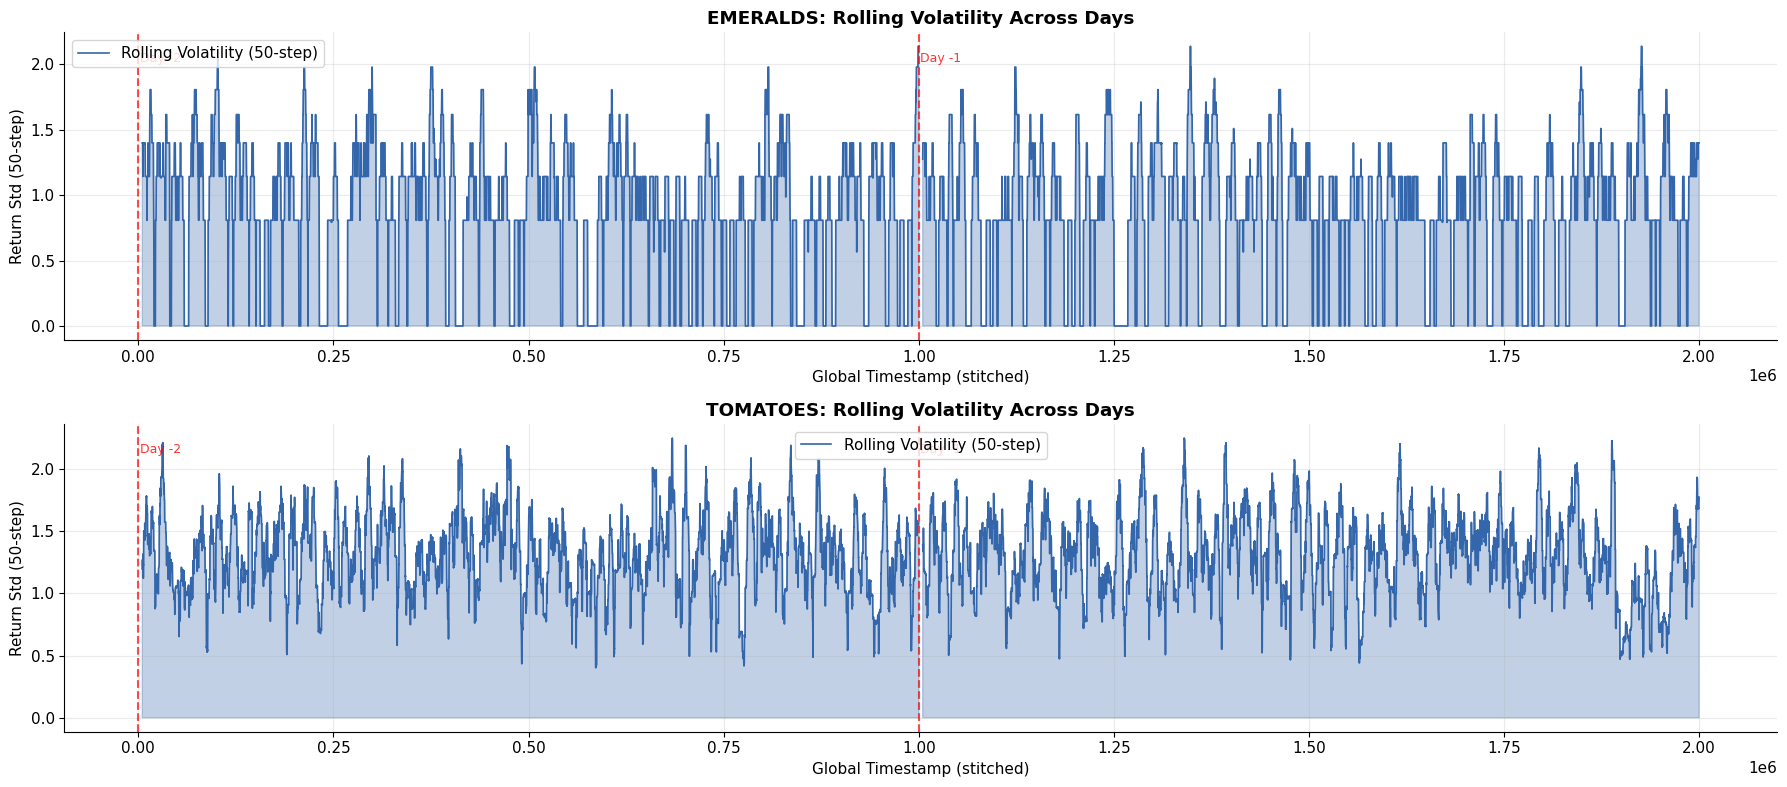

In [8]:
# ── Rolling volatility across days (stitched timeline) ───────────────────────
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(18, 4 * len(PRODUCTS)))
if len(PRODUCTS) == 1: axes = [axes]

for ax, p in zip(axes, PRODUCTS):
    segments = []
    offset = 0
    day_boundaries = []
    for d in DAYS:
        df = prices[(p, d)].copy()
        df['global_ts'] = df['timestamp'] + offset
        df['rolling_vol'] = df['mid_price'].diff().rolling(50).std()
        segments.append(df)
        day_boundaries.append(offset)
        offset += df['timestamp'].max() + 100

    combined = pd.concat(segments)
    ax.fill_between(combined['global_ts'], combined['rolling_vol'],
                    alpha=0.3, color=COLORS['pnl'])
    ax.plot(combined['global_ts'], combined['rolling_vol'],
            lw=1.2, color=COLORS['pnl'], label='Rolling Volatility (50-step)')

    # Day boundary lines
    for b, d in zip(day_boundaries, DAYS):
        ax.axvline(b, color='red', lw=1.5, linestyle='--', alpha=0.7)
        ax.text(b + 2000, ax.get_ylim()[1] * 0.9, f'Day {d}',
                fontsize=9, color='red', alpha=0.8)

    ax.set_title(f'{p}: Rolling Volatility Across Days', fontweight='bold')
    ax.set_xlabel('Global Timestamp (stitched)')
    ax.set_ylabel('Return Std (50-step)')
    ax.legend()

plt.tight_layout()
plt.show()

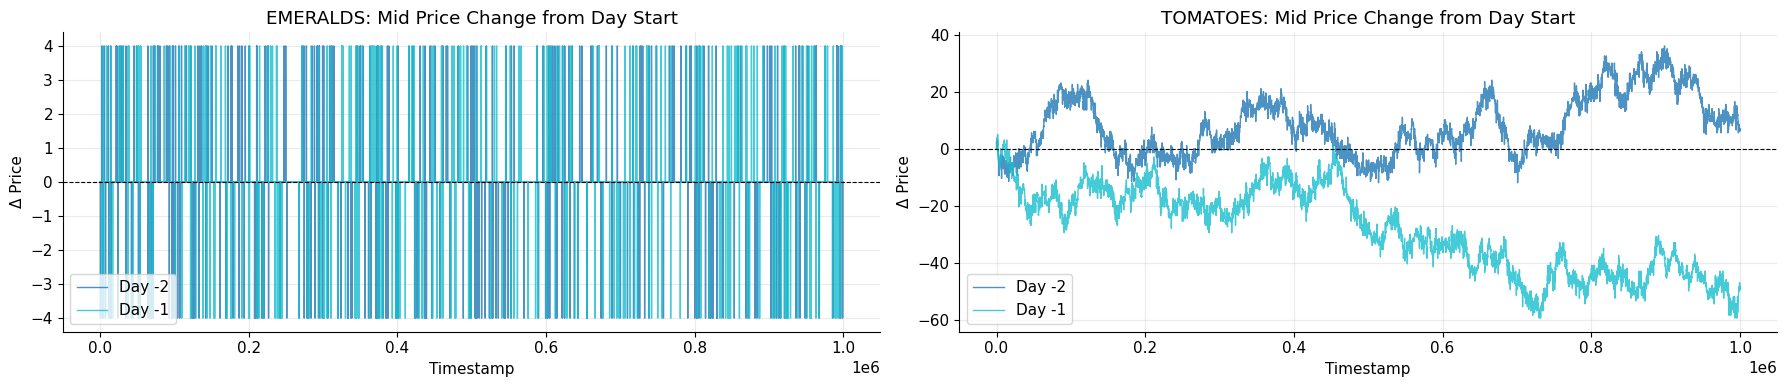

In [9]:
# ── Price level across days (normalised to day start) ────────────────────────
fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(18, 4))
if len(PRODUCTS) == 1: axes = [axes]

day_colors = plt.cm.tab10(np.linspace(0, 1, len(DAYS)))

for ax, p in zip(axes, PRODUCTS):
    for d, color in zip(DAYS, day_colors):
        df = prices[(p, d)]
        start = df['mid_price'].iloc[0]
        ax.plot(df['timestamp'], df['mid_price'] - start,
                lw=1.0, alpha=0.8, color=color, label=f'Day {d}')
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(f'{p}: Mid Price Change from Day Start')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Δ Price')
    ax.legend()

plt.tight_layout()
plt.show()

<a id='5-spread'></a>
## 5. Spread & Edge Analysis

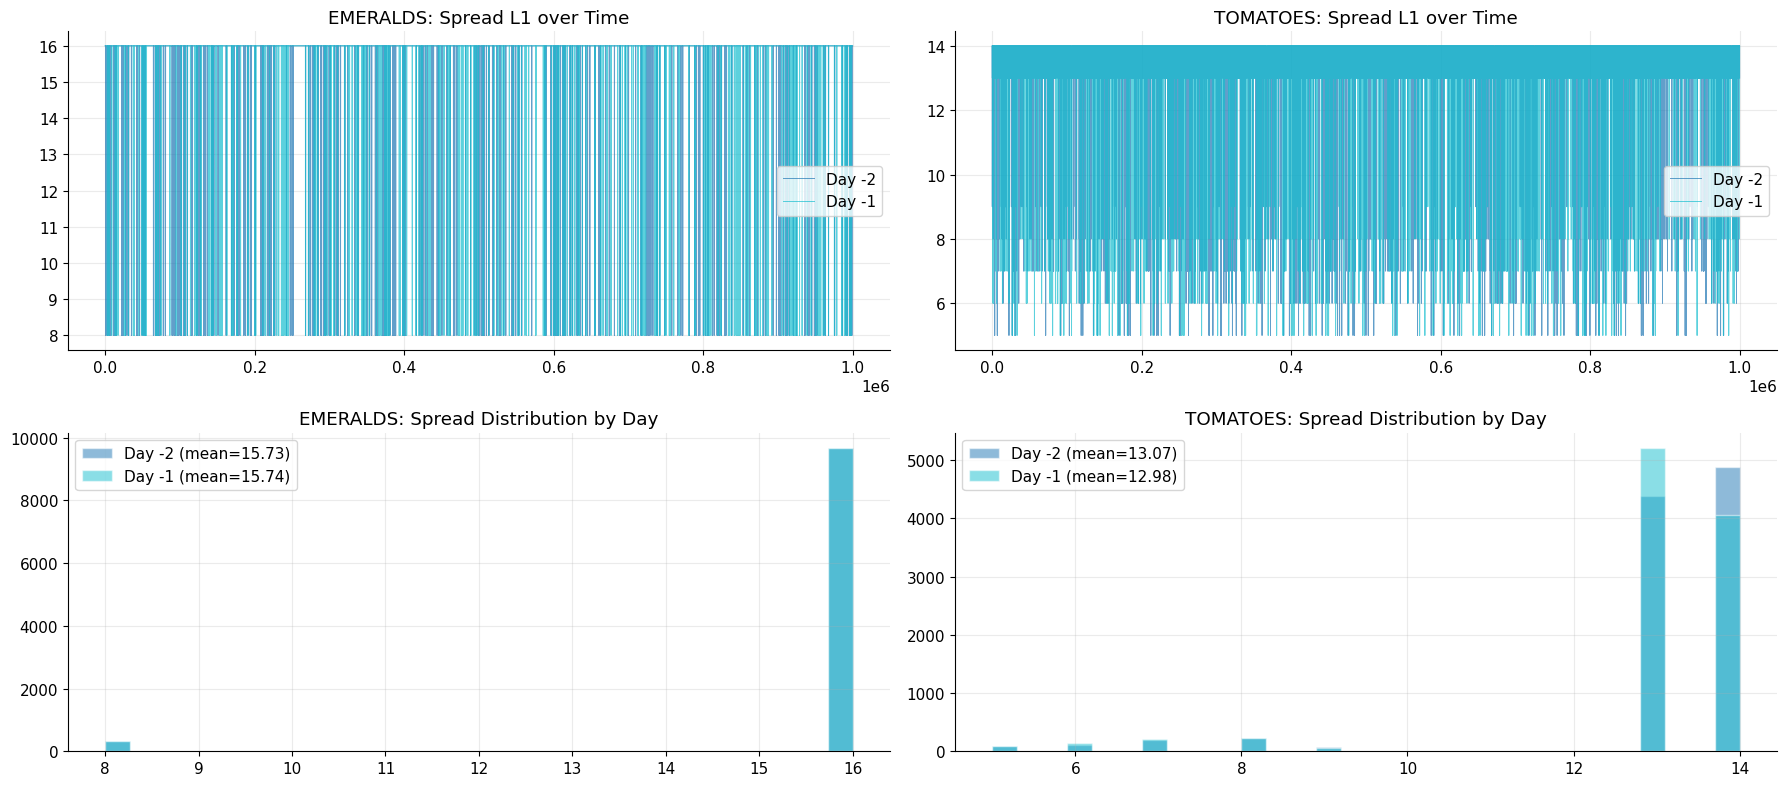


Spread summary table:


,product,day,mean,std,min,max,edge_per_side
0,EMERALDS,-2,15.734,1.435,8,16,7.867
1,EMERALDS,-1,15.743,1.410,8,16,7.872
2,TOMATOES,-2,13.065,1.755,5,14,6.533
3,TOMATOES,-1,12.975,1.753,5,14,6.488


In [10]:
fig, axes = plt.subplots(2, len(PRODUCTS), figsize=(9 * len(PRODUCTS), 8))
if len(PRODUCTS) == 1: axes = axes.reshape(2, 1)

for col, p in enumerate(PRODUCTS):
    for d, color in zip(DAYS, day_colors):
        df = prices[(p, d)]
        axes[0, col].plot(df['timestamp'], df['spread_L1'],
                          lw=0.7, alpha=0.7, color=color, label=f'Day {d}')
    axes[0, col].set_title(f'{p}: Spread L1 over Time')
    axes[0, col].legend()

    # Distribution comparison across days
    for d, color in zip(DAYS, day_colors):
        df = prices[(p, d)]
        axes[1, col].hist(df['spread_L1'], bins=30, alpha=0.5, color=color,
                          label=f'Day {d} (mean={df["spread_L1"].mean():.2f})', edgecolor='white')
    axes[1, col].set_title(f'{p}: Spread Distribution by Day')
    axes[1, col].legend()

plt.tight_layout()
plt.show()

print('\nSpread summary table:')
spr_data = []
for p in PRODUCTS:
    for d in DAYS:
        s = prices[(p,d)]['spread_L1']
        spr_data.append({'product':p,'day':d,'mean':round(s.mean(),3),
                         'std':round(s.std(),3),'min':s.min(),'max':s.max(),
                         'edge_per_side': round(s.mean()/2, 3)})
display(pd.DataFrame(spr_data))

<a id='6-trueprice'></a>
## 6. True Price Identification — Fixed vs Drifting

- **Fixed true price** → market making around known constant (Rainforest Resin archetype)
- **Drifting / random walk** → market make around rolling Wall Mid (Kelp archetype)  
- **Mean-reverting drifting** → also fade large moves

In [11]:
def classify_price_process(product):
    results = []
    for d in DAYS:
        df  = prices[(product, d)]
        mid = df['mid_price']
        ret = mid.diff().dropna()
        adf_p = adfuller(mid.dropna(), maxlag=10, autolag='AIC')[1]

        unique_levels = mid.nunique()
        is_fixed = (mid.std() < 5) and (unique_levels <= 5)
        lag1 = ret.autocorr(1)

        if is_fixed:
            ptype = f'FIXED ~ {round(mid.mean())}'
        elif adf_p < 0.05 and lag1 < -0.1:
            ptype = 'MEAN-REVERTING (stationary)'
        elif adf_p >= 0.05:
            ptype = 'RANDOM WALK (non-stationary)'
        else:
            ptype = 'STATIONARY (weakly)'

        results.append({
            'product': product, 'day': d,
            'type': ptype,
            'mean': round(mid.mean(), 2),
            'std': round(mid.std(), 4),
            'unique_levels': unique_levels,
            'lag1_acf': round(lag1, 4),
            'adf_pval': round(adf_p, 5),
            'recommended_fv': f'fixed={round(mid.mean())}' if is_fixed else 'wall_mid',
        })
    return results

all_classifications = []
for p in PRODUCTS:
    all_classifications.extend(classify_price_process(p))

cls_df = pd.DataFrame(all_classifications)
print('Price Process Classification:')
display(cls_df)

# Store recommended fair value per product (consistent across days = good)
FAIR_VALUE_TYPE = {}
TRUE_PRICES = {}
for p in PRODUCTS:
    sub = cls_df[cls_df['product']==p]
    if all('FIXED' in t for t in sub['type']):
        tp = round(sub['mean'].mean())
        FAIR_VALUE_TYPE[p] = 'fixed'
        TRUE_PRICES[p] = tp
        print(f'{p}: ✅ Fixed true price = {tp}')
    else:
        FAIR_VALUE_TYPE[p] = 'wall_mid'
        TRUE_PRICES[p] = None
        print(f'{p}: 📈 Drifting — use wall_mid. lag1={sub["lag1_acf"].mean():.3f}')

Price Process Classification:


,product,day,type,mean,std,unique_levels,lag1_acf,adf_pval,recommended_fv
0,EMERALDS,-2,FIXED ~ 10000,10000.00,0.7300,3,-0.4848,0.00000,fixed=10000
1,EMERALDS,-1,FIXED ~ 10000,10000.00,0.7167,3,-0.4904,0.00000,fixed=10000
2,TOMATOES,-2,RANDOM WALK (non-stationary),5007.95,10.2887,96,-0.4280,0.14261,wall_mid
3,TOMATOES,-1,RANDOM WALK (non-stationary),4977.57,14.5785,129,-0.4125,0.25907,wall_mid


EMERALDS: ✅ Fixed true price = 10000
TOMATOES: 📈 Drifting — use wall_mid. lag1=-0.420


<a id='7-orderbook'></a>
## 7. Orderbook Visualisation
Bid/ask levels + Wall Mid + trades, plotted per product per day.

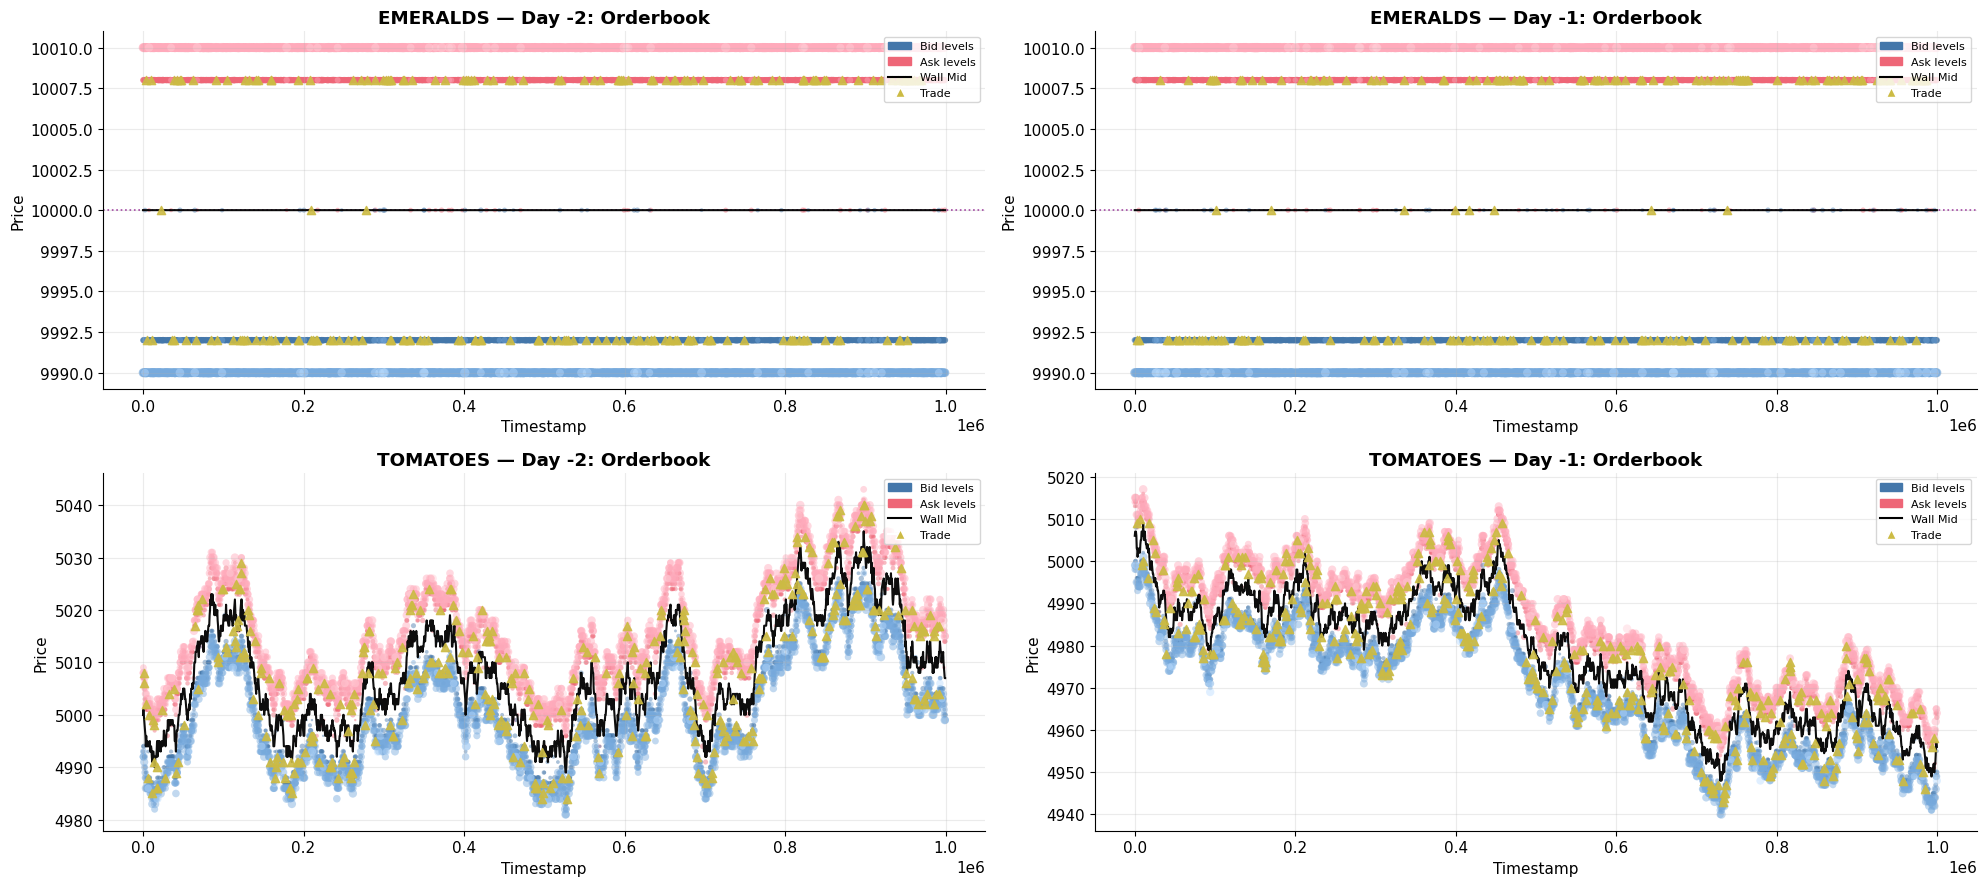

In [12]:
def plot_orderbook_panel(product, day, ax, downsample=5):
    df = prices[(product, day)].iloc[::downsample]
    tr = trades[(product, day)]

    ask_levels = [('ask_price_1','ask_volume_1','#EE6677'),
                  ('ask_price_2','ask_volume_2','#FFAABB'),
                  ('ask_price_3','ask_volume_3','#FFD0D8')]
    bid_levels = [('bid_price_1','bid_volume_1','#4477AA'),
                  ('bid_price_2','bid_volume_2','#77AADD'),
                  ('bid_price_3','bid_volume_3','#BBDDFF')]

    for pc, vc, color in ask_levels + bid_levels:
        if pc in df.columns:
            valid = df[pc].notna()
            sz = df.loc[valid, vc].fillna(1).clip(0, 50) * 1.5 if vc in df.columns else 8
            ax.scatter(df.loc[valid,'timestamp'], df.loc[valid, pc],
                       s=sz, c=color, alpha=0.45, linewidths=0)

    ax.plot(df['timestamp'], df['wall_mid'], c=COLORS['wall_mid'],
            lw=1.5, alpha=0.95, label='Wall Mid', zorder=4)

    if TRUE_PRICES.get(product):
        ax.axhline(TRUE_PRICES[product], color='purple', lw=1.2,
                   linestyle=':', alpha=0.7, label=f'True={TRUE_PRICES[product]}')

    if len(tr) > 0:
        ax.scatter(tr['timestamp'], tr['price'], marker='^', s=35,
                   c=COLORS['trade'], zorder=5, alpha=0.9, label='Trade')

    bid_p = mpatches.Patch(color='#4477AA', label='Bid levels')
    ask_p = mpatches.Patch(color='#EE6677', label='Ask levels')
    wm_l  = plt.Line2D([0],[0], color='black', label='Wall Mid')
    tr_p  = plt.Line2D([0],[0], marker='^', color='w', markerfacecolor=COLORS['trade'], markersize=7, label='Trade')
    ax.legend(handles=[bid_p, ask_p, wm_l, tr_p], loc='upper right', fontsize=8)
    ax.set_title(f'{product} — Day {day}: Orderbook', fontweight='bold')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Price')


n_rows = len(PRODUCTS)
n_cols = len(DAYS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10 * n_cols, 4.5 * n_rows))
if n_rows == 1 and n_cols == 1: axes = np.array([[axes]])
elif n_rows == 1: axes = axes.reshape(1, -1)
elif n_cols == 1: axes = axes.reshape(-1, 1)

for row, p in enumerate(PRODUCTS):
    for col, d in enumerate(DAYS):
        plot_orderbook_panel(p, d, axes[row, col])

plt.tight_layout()
plt.show()

<a id='8-trades'></a>
## 8. Trade Classification & Edge Distribution

In [13]:
def classify_trades(trades_df, prices_df):
    if len(trades_df) == 0:
        return trades_df.copy()
    p_ts = prices_df['timestamp'].values
    rows = []
    for _, t in trades_df.iterrows():
        idx = np.searchsorted(p_ts, t['timestamp'], side='right') - 1
        idx = max(0, min(idx, len(prices_df)-1))
        row = prices_df.iloc[idx]
        tp = t['price']
        if tp >= row.get('ask_price_1', np.inf):
            direction = 'buy_taker'
        elif tp <= row.get('bid_price_1', -np.inf):
            direction = 'sell_taker'
        else:
            direction = 'mid'
        wm = row.get('wall_mid', row['mid_price'])
        rows.append({'direction': direction, 'edge_vs_wall': tp - wm,
                     'bid1': row.get('bid_price_1'), 'ask1': row.get('ask_price_1'),
                     'wall_mid': wm})
    return trades_df.assign(**pd.DataFrame(rows, index=trades_df.index))


for p in PRODUCTS:
    for d in DAYS:
        trades[(p,d)] = classify_trades(trades[(p,d)], prices[(p,d)])
    trades_prod[p] = classify_trades(trades_prod[p], prices_prod[p])

print('Trade classification complete ✓')

# Summary table
rows = []
for p in PRODUCTS:
    for d in DAYS:
        t = trades[(p,d)]
        if len(t) == 0: continue
        vc = t['direction'].value_counts()
        rows.append({
            'product':p,'day':d,
            'buy_taker':   vc.get('buy_taker',0),
            'sell_taker':  vc.get('sell_taker',0),
            'mid':         vc.get('mid',0),
            'edge_buy_mean':  round(t[t.direction=='buy_taker']['edge_vs_wall'].mean(),3) if vc.get('buy_taker',0)>0 else np.nan,
            'edge_sell_mean': round(t[t.direction=='sell_taker']['edge_vs_wall'].mean(),3) if vc.get('sell_taker',0)>0 else np.nan,
        })
display(pd.DataFrame(rows))

Trade classification complete ✓


,product,day,buy_taker,sell_taker,mid,edge_buy_mean,edge_sell_mean
0,EMERALDS,-2,91,100,0,7.912,-7.840
1,EMERALDS,-1,104,104,0,7.615,-7.769
2,TOMATOES,-2,189,208,0,6.487,-6.361
3,TOMATOES,-1,198,225,0,6.490,-6.447


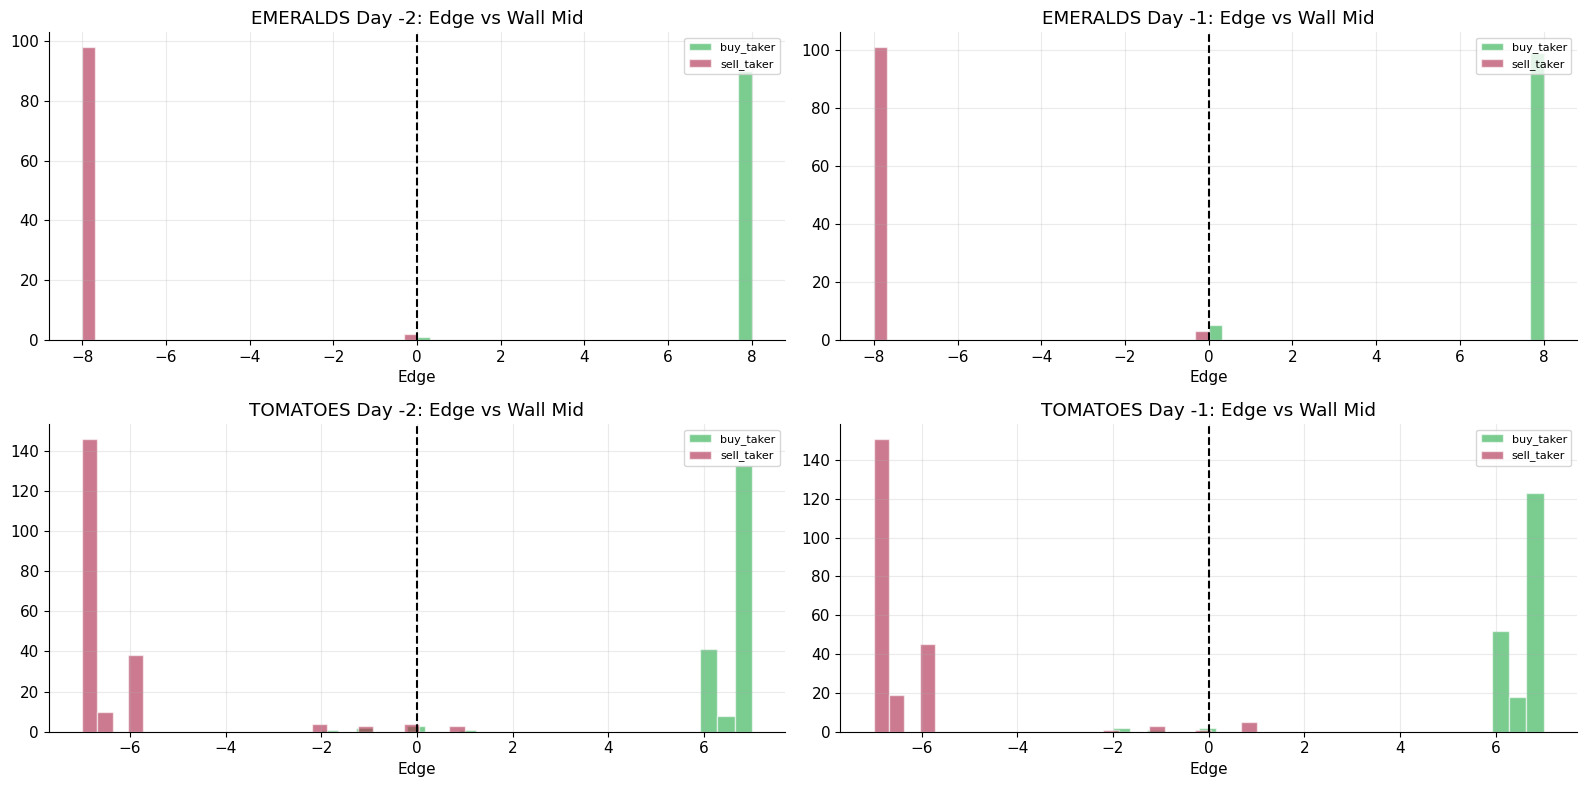

In [14]:
# Edge distribution grid: product × day
fig, axes = plt.subplots(len(PRODUCTS), len(DAYS), figsize=(8*len(DAYS), 4*len(PRODUCTS)))
if len(PRODUCTS) == 1 and len(DAYS) == 1: axes = np.array([[axes]])
elif len(PRODUCTS) == 1: axes = axes.reshape(1,-1)
elif len(DAYS) == 1: axes = axes.reshape(-1,1)

dir_colors = {'buy_taker': COLORS['signal_buy'], 'sell_taker': COLORS['signal_sell'], 'mid': 'gray'}

for row, p in enumerate(PRODUCTS):
    for col, d in enumerate(DAYS):
        ax = axes[row, col]
        t = trades[(p,d)]
        if len(t) == 0:
            ax.text(0.5, 0.5, 'No trades', ha='center', va='center', transform=ax.transAxes)
            continue
        for direction, grp in t.groupby('direction'):
            ax.hist(grp['edge_vs_wall'].dropna(), bins=25, alpha=0.6,
                    color=dir_colors.get(direction,'gray'), label=direction, edgecolor='white')
        ax.axvline(0, color='black', lw=1.5, linestyle='--')
        ax.set_title(f'{p} Day {d}: Edge vs Wall Mid')
        ax.set_xlabel('Edge')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

<a id='9-informed'></a>
## 9. Informed Trader Detection

Searching for **Olivia-style** patterns: trades at running daily extremes (buying at daily low, selling at daily high) with potentially fixed quantity. We scan across all days and look for consistency.

In [15]:
# Named trader IDs across all data
print('=== Named Trader IDs ===')
for col in ['buyer','seller']:
    ids = trades_all[col].dropna()
    if len(ids) > 0:
        print(f'{col}: {ids.unique().tolist()}')
    else:
        print(f'{col}: (all anonymous in this round)')

print()
print('=== Trade Quantity Distributions ===')
for p in PRODUCTS:
    for d in DAYS:
        t = trades[(p,d)]
        if len(t) == 0: continue
        vc = t['quantity'].value_counts().sort_index()
        # Flag suspicious fixed quantities
        suspicious = vc[vc >= 3].index.tolist()  # quantities appearing 3+ times
        print(f'{p} Day {d}: {dict(vc)}', end='')
        if suspicious:
            print(f'  ← repeated quantities: {suspicious}', end='')
        print()

=== Named Trader IDs ===
buyer: (all anonymous in this round)
seller: (all anonymous in this round)

=== Trade Quantity Distributions ===
EMERALDS Day -2: {3: np.int64(30), 4: np.int64(32), 5: np.int64(37), 6: np.int64(37), 7: np.int64(25), 8: np.int64(30)}  ← repeated quantities: [3, 4, 5, 6, 7, 8]
EMERALDS Day -1: {3: np.int64(30), 4: np.int64(31), 5: np.int64(37), 6: np.int64(48), 7: np.int64(34), 8: np.int64(28)}  ← repeated quantities: [3, 4, 5, 6, 7, 8]
TOMATOES Day -2: {2: np.int64(96), 3: np.int64(94), 4: np.int64(99), 5: np.int64(107), 6: np.int64(1)}  ← repeated quantities: [2, 3, 4, 5]
TOMATOES Day -1: {2: np.int64(113), 3: np.int64(116), 4: np.int64(103), 5: np.int64(90), 6: np.int64(1)}  ← repeated quantities: [2, 3, 4, 5]


In [16]:
def detect_informed_trader(product, day, extrema_tolerance=3):
    """
    Tag trades that occur at/near the running daily min or max.
    extrema_tolerance: price range around the running extreme to flag.
    """
    tr = trades[(product, day)].copy().sort_values('timestamp').reset_index(drop=True)
    pr = prices[(product, day)].copy().sort_values('timestamp')
    p_ts = pr['timestamp'].values
    mids = pr['mid_price'].values

    run_min, run_max = [], []
    for ts in tr['timestamp'].values:
        mask = p_ts <= ts
        subset = mids[mask]
        run_min.append(subset.min() if len(subset) else np.nan)
        run_max.append(subset.max() if len(subset) else np.nan)

    tr['running_min'] = run_min
    tr['running_max'] = run_max
    tr['near_low']   = tr['price'] <= tr['running_min'] + extrema_tolerance
    tr['near_high']  = tr['price'] >= tr['running_max'] - extrema_tolerance
    tr['is_new_low']  = tr['price'] <= tr['running_min']
    tr['is_new_high'] = tr['price'] >= tr['running_max']
    return tr


informed_trades = {}
print('Informed Trader Detection:')
print('-' * 60)
for p in PRODUCTS:
    for d in DAYS:
        it = detect_informed_trader(p, d)
        informed_trades[(p,d)] = it
        n_low  = it['near_low'].sum()
        n_high = it['near_high'].sum()
        print(f'{p} Day {d:3d}: near-low={n_low:3d}, near-high={n_high:3d}', end='')
        # Consistent across days?
        if n_low > 0 or n_high > 0:
            print(f'  ← potential informed signal')
        else:
            print()

# Cross-day consistency check
print()
print('Cross-day informed signal consistency:')
for p in PRODUCTS:
    consistent_low  = all(informed_trades[(p,d)]['near_low'].sum() > 0 for d in DAYS)
    consistent_high = all(informed_trades[(p,d)]['near_high'].sum() > 0 for d in DAYS)
    if consistent_low or consistent_high:
        print(f'  {p}: CONSISTENT INFORMED SIGNAL — low={consistent_low}, high={consistent_high} ✅')
    else:
        print(f'  {p}: inconsistent or no informed signal across days')

Informed Trader Detection:
------------------------------------------------------------
EMERALDS Day  -2: near-low= 98, near-high= 90  ← potential informed signal
EMERALDS Day  -1: near-low=101, near-high= 99  ← potential informed signal
TOMATOES Day  -2: near-low= 52, near-high= 60  ← potential informed signal
TOMATOES Day  -1: near-low= 97, near-high=  4  ← potential informed signal

Cross-day informed signal consistency:
  EMERALDS: CONSISTENT INFORMED SIGNAL — low=True, high=True ✅
  TOMATOES: CONSISTENT INFORMED SIGNAL — low=True, high=True ✅


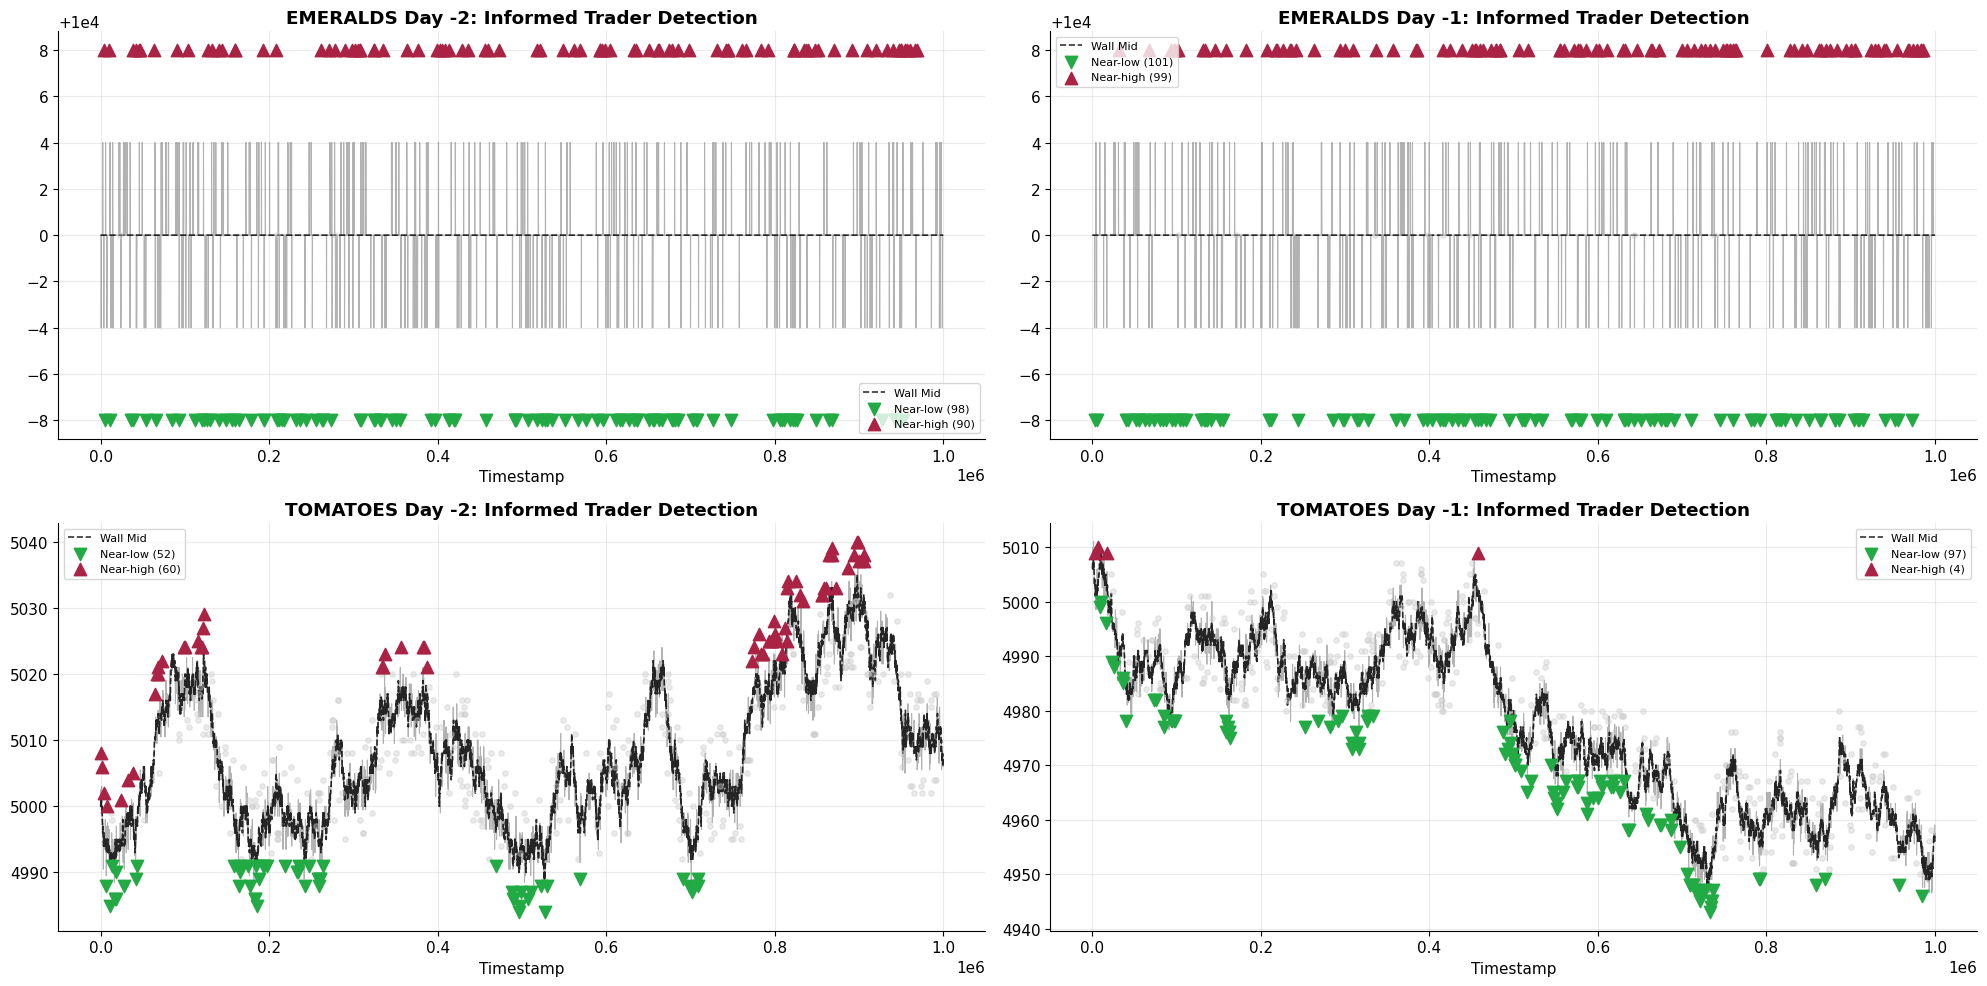

In [17]:
# Visualise informed traders on orderbook
fig, axes = plt.subplots(len(PRODUCTS), len(DAYS), figsize=(10*len(DAYS), 5*len(PRODUCTS)))
if len(PRODUCTS) == 1 and len(DAYS) == 1: axes = np.array([[axes]])
elif len(PRODUCTS) == 1: axes = axes.reshape(1,-1)
elif len(DAYS) == 1: axes = axes.reshape(-1,1)

for row, p in enumerate(PRODUCTS):
    for col, d in enumerate(DAYS):
        ax = axes[row, col]
        df = prices[(p,d)]
        tr = informed_trades[(p,d)]

        ax.plot(df['timestamp'], df['mid_price'], lw=0.8, alpha=0.6, color='gray')
        ax.plot(df['timestamp'], df['wall_mid'],  lw=1.2, color='black', alpha=0.8,
                linestyle='--', label='Wall Mid')

        reg = tr[~tr['near_low'] & ~tr['near_high']]
        ax.scatter(reg['timestamp'], reg['price'], s=15, c='#CCCCCC', alpha=0.4,
                   marker='o', zorder=2)

        low_tr  = tr[tr['near_low']]
        high_tr = tr[tr['near_high']]
        if len(low_tr) > 0:
            ax.scatter(low_tr['timestamp'], low_tr['price'], s=80, c=COLORS['signal_buy'],
                       marker='v', label=f'Near-low ({len(low_tr)})', zorder=5)
        if len(high_tr) > 0:
            ax.scatter(high_tr['timestamp'], high_tr['price'], s=80, c=COLORS['signal_sell'],
                       marker='^', label=f'Near-high ({len(high_tr)})', zorder=5)

        ax.set_title(f'{p} Day {d}: Informed Trader Detection', fontweight='bold')
        ax.set_xlabel('Timestamp')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

<a id='10-acf'></a>
## 10. Return Structure & Autocorrelation

We compare lag-1 ACF across days — a stable negative ACF means mean-reversion is a real structural feature, not noise.

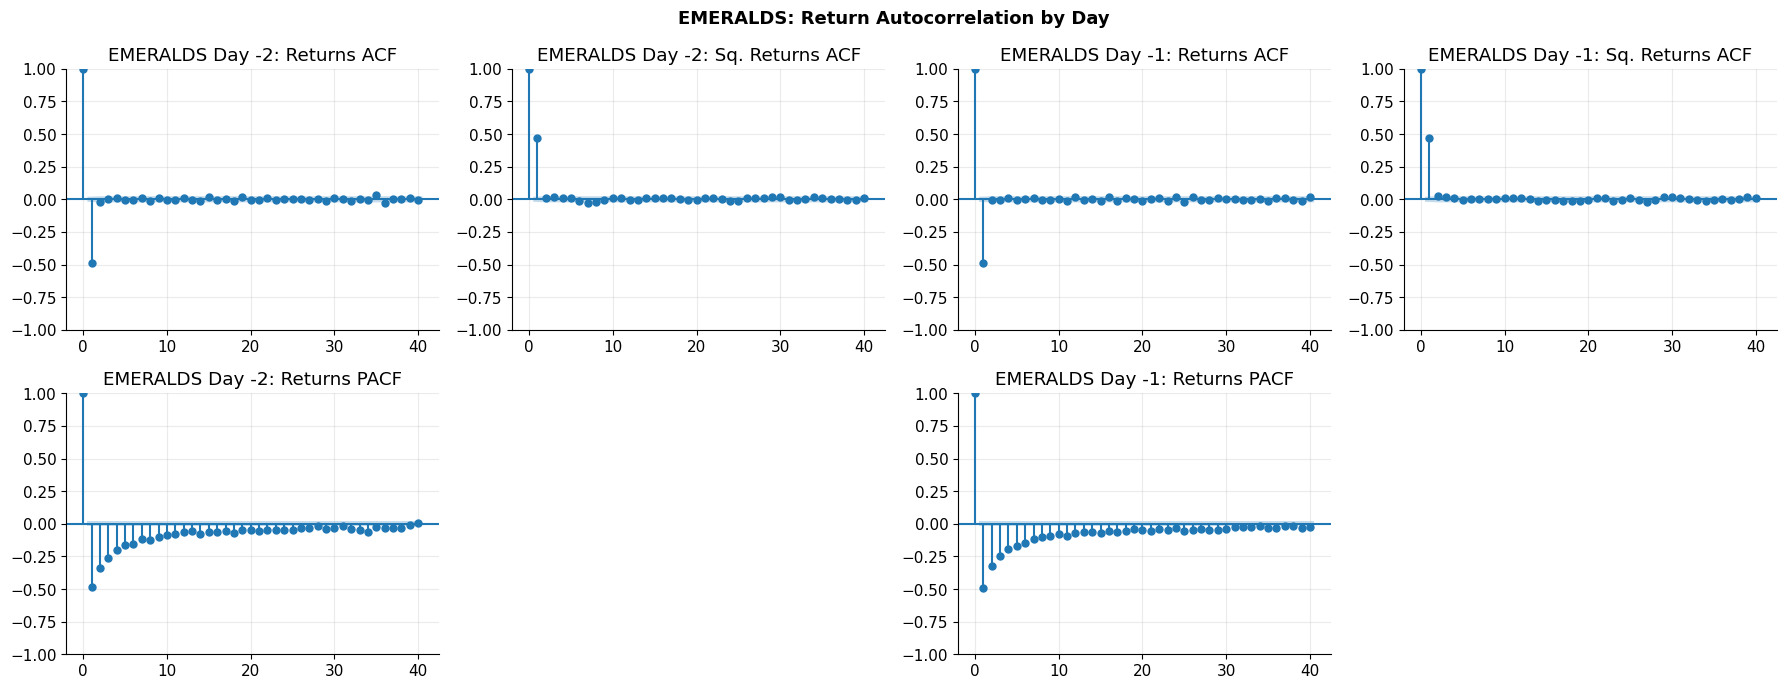

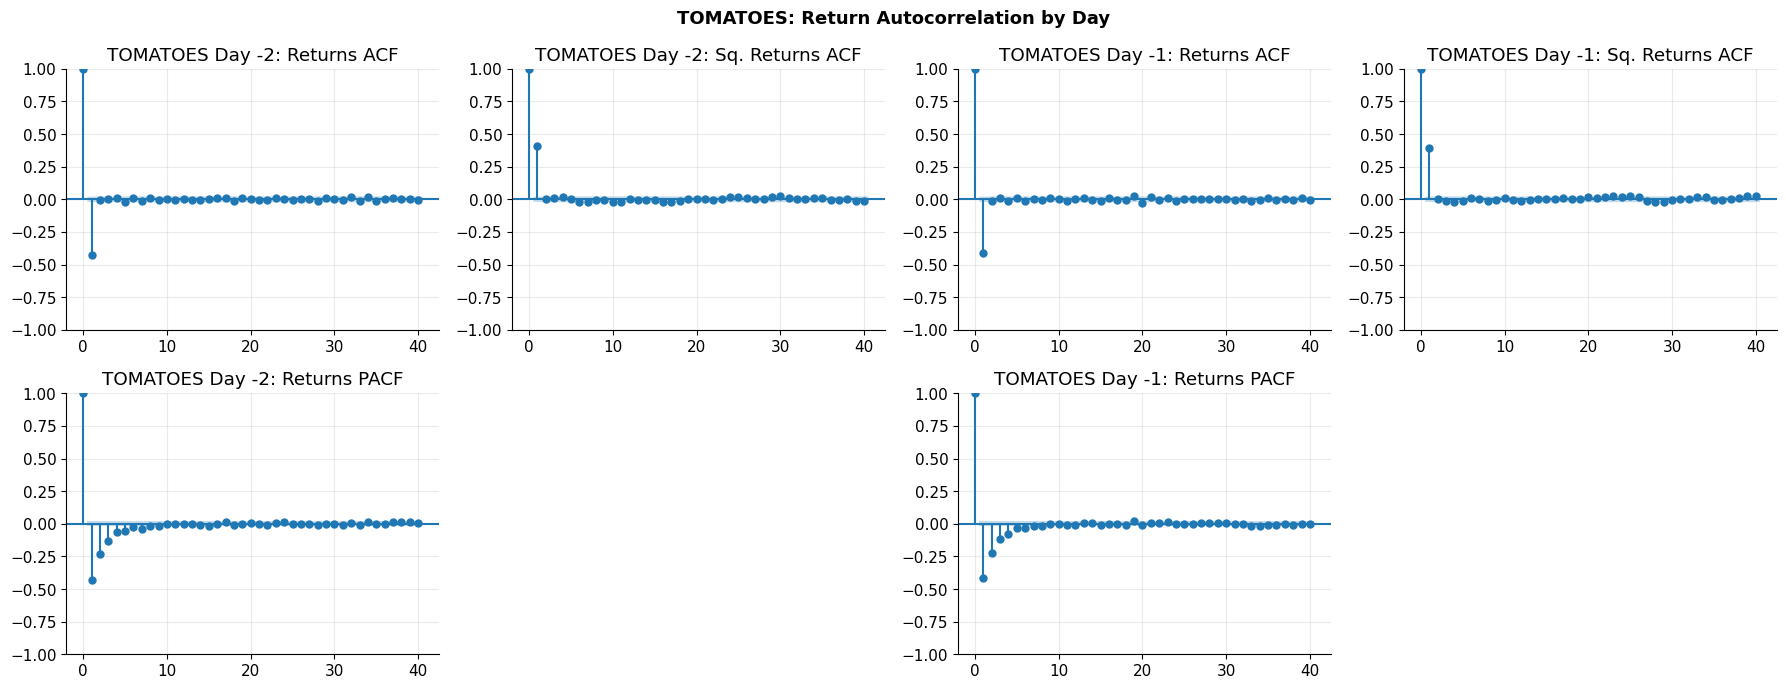

In [18]:
# ── ACF / PACF plots per product ─────────────────────────────────────────────
for p in PRODUCTS:
    fig, axes = plt.subplots(2, 2 * len(DAYS), figsize=(9 * len(DAYS), 7))
    if len(DAYS) == 1: axes = axes.reshape(2,2)

    for col, d in enumerate(DAYS):
        mid = prices[(p,d)]['mid_price']
        ret = mid.diff().dropna()
        plot_acf(ret,    lags=40, ax=axes[0, col*2],   title=f'{p} Day {d}: Returns ACF')
        plot_acf(ret**2, lags=40, ax=axes[0, col*2+1], title=f'{p} Day {d}: Sq. Returns ACF')
        plot_pacf(ret,   lags=40, ax=axes[1, col*2],   title=f'{p} Day {d}: Returns PACF')
        axes[1, col*2+1].axis('off')

    plt.suptitle(f'{p}: Return Autocorrelation by Day', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [19]:
# ── Cross-day ACF stability summary ──────────────────────────────────────────
print('Autocorrelation Stability Across Days')
print('(Stable lag-1 = structural feature worth exploiting)')
print('=' * 70)

acf_rows = []
for p in PRODUCTS:
    lags_by_day = {}
    for d in DAYS:
        ret = prices[(p,d)]['mid_price'].diff().dropna()
        lags_by_day[d] = {f'lag{k}': round(ret.autocorr(k), 4) for k in [1,2,3,5,10]}
        lags_by_day[d]['ret_std'] = round(ret.std(), 4)
        lags_by_day[d]['day'] = d
        lags_by_day[d]['product'] = p
        acf_rows.append(lags_by_day[d])

    # Stability check
    lag1_vals = [lags_by_day[d]['lag1'] for d in DAYS]
    stable = np.std(lag1_vals) < 0.05
    mean_lag1 = np.mean(lag1_vals)
    print(f'{p}: lag-1 values = {lag1_vals}')
    print(f'     mean={mean_lag1:.4f}, std={np.std(lag1_vals):.4f}'
          f' → {"✅ STABLE" if stable else "⚠ UNSTABLE"}', end='')
    if abs(mean_lag1) > 0.2 and stable:
        feat = 'MEAN-REVERTING' if mean_lag1 < 0 else 'TRENDING'
        print(f' — {feat} signal is RELIABLE')
    else:
        print()

display(pd.DataFrame(acf_rows).set_index(['product','day']))

Autocorrelation Stability Across Days
(Stable lag-1 = structural feature worth exploiting)
EMERALDS: lag-1 values = [np.float64(-0.4848), np.float64(-0.4904)]
     mean=-0.4876, std=0.0028 → ✅ STABLE — MEAN-REVERTING signal is RELIABLE
TOMATOES: lag-1 values = [np.float64(-0.428), np.float64(-0.4125)]
     mean=-0.4203, std=0.0078 → ✅ STABLE — MEAN-REVERTING signal is RELIABLE


lag1    lag2    lag3    lag5   lag10  ret_std
product  day                                                 
EMERALDS -2  -0.4848 -0.0227  0.0015 -0.0015 -0.0015   1.0277
         -1  -0.4904 -0.0048 -0.0080 -0.0080  0.0048   0.9993
TOMATOES -2  -0.4280 -0.0036 -0.0005 -0.0182  0.0059   1.3450
         -1  -0.4125 -0.0153  0.0073  0.0112 -0.0005   1.3372

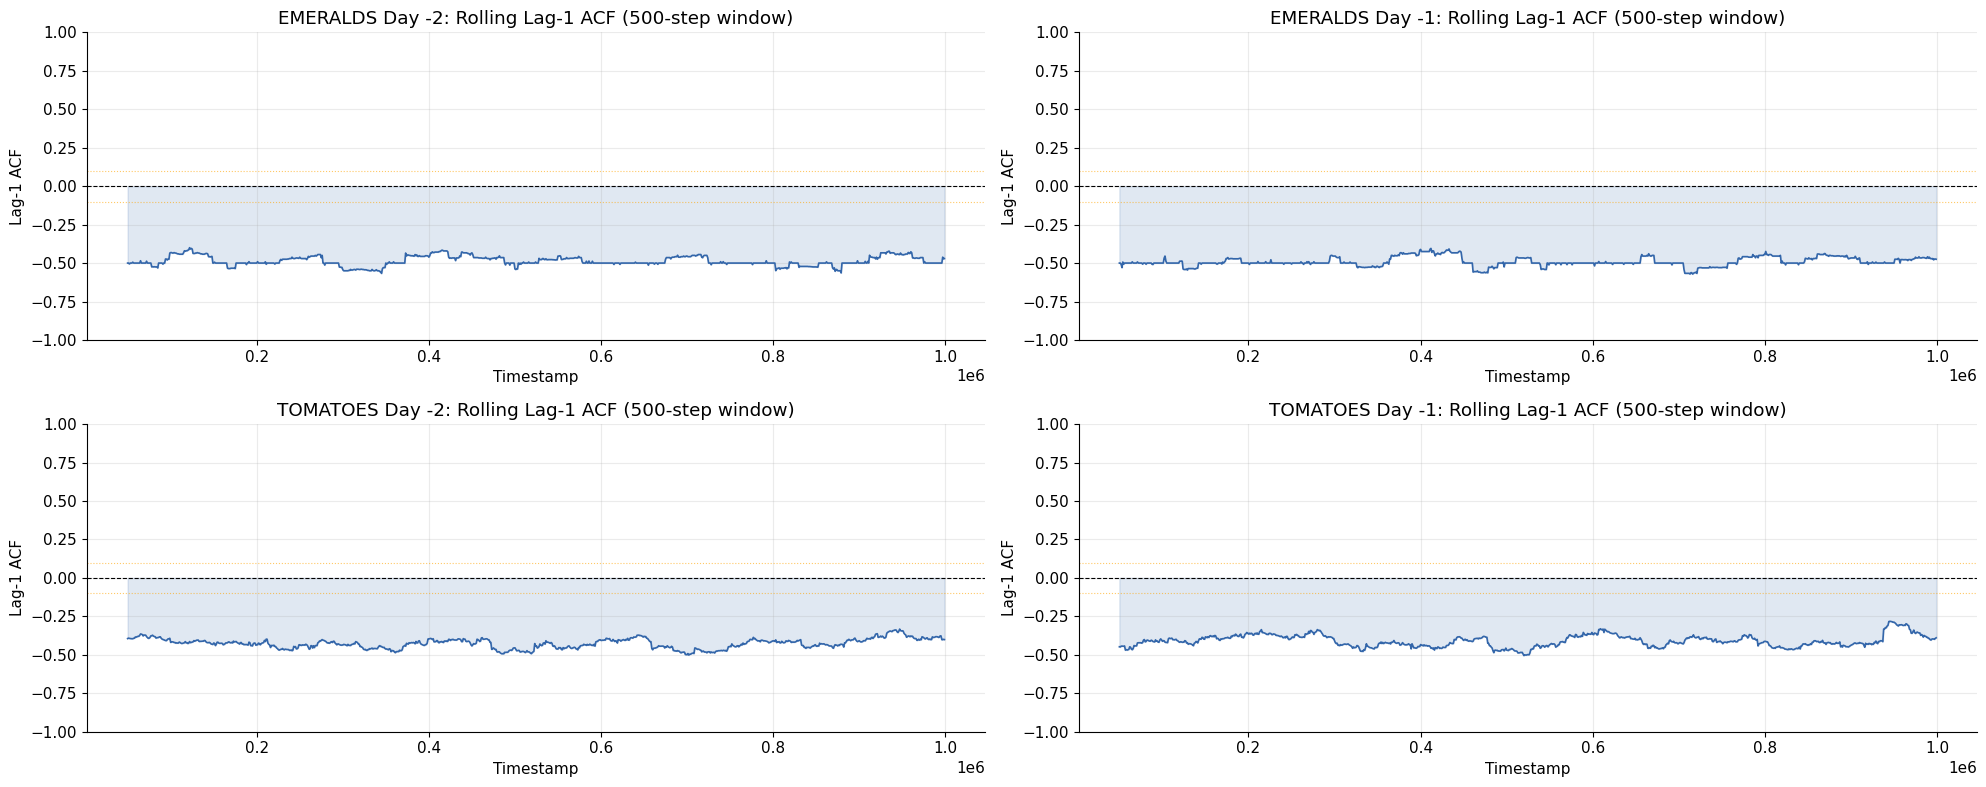

In [20]:
# ── Rolling window lag-1 ACF — detect intra-day regime shifts ────────────────
WINDOW = 500  # timesteps

fig, axes = plt.subplots(len(PRODUCTS), len(DAYS), figsize=(10*len(DAYS), 4*len(PRODUCTS)))
if len(PRODUCTS) == 1 and len(DAYS) == 1: axes = np.array([[axes]])
elif len(PRODUCTS) == 1: axes = axes.reshape(1,-1)
elif len(DAYS) == 1: axes = axes.reshape(-1,1)

for row, p in enumerate(PRODUCTS):
    for col, d in enumerate(DAYS):
        ax = axes[row, col]
        mid = prices[(p,d)]['mid_price']
        ret = mid.diff()

        roll_acf = [
            ret.iloc[max(0,i-WINDOW):i].autocorr(1)
            for i in range(WINDOW, len(ret), 10)
        ]
        ts_idx = prices[(p,d)]['timestamp'].iloc[WINDOW::10].values[:len(roll_acf)]

        ax.plot(ts_idx, roll_acf, lw=1.2, color=COLORS['pnl'])
        ax.axhline(0, color='black', lw=0.8, linestyle='--')
        ax.axhline( 0.1, color='orange', lw=0.8, linestyle=':', alpha=0.6)
        ax.axhline(-0.1, color='orange', lw=0.8, linestyle=':', alpha=0.6)
        ax.fill_between(ts_idx, roll_acf, 0, alpha=0.15, color=COLORS['pnl'])
        ax.set_title(f'{p} Day {d}: Rolling Lag-1 ACF ({WINDOW}-step window)')
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Lag-1 ACF')
        ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

<a id='11-bots'></a>
## 11. Bot Behavior Profiling
Checking for consistent quote sizes, fixed spreads, and any timing patterns that could be front-run.

In [21]:
print('Bot Behavior Summary Across Days')
print('=' * 70)

bot_rows = []
for p in PRODUCTS:
    for d in DAYS:
        df = prices[(p,d)]
        bv1 = df['bid_volume_1'].dropna()
        av1 = df['ask_volume_1'].dropna()

        bid_chg_pct = 100 * (df['bid_price_1'].diff() != 0).mean()
        ask_chg_pct = 100 * (df['ask_price_1'].diff() != 0).mean()
        vol_corr = bv1.corr(av1)

        # Check if volumes are deterministic (very low std relative to mean)
        bv_cv = bv1.std() / bv1.mean() if bv1.mean() > 0 else np.nan  # coefficient of variation

        bot_rows.append({
            'product': p, 'day': d,
            'bid_vol1_mean': round(bv1.mean(),2), 'bid_vol1_std': round(bv1.std(),2),
            'ask_vol1_mean': round(av1.mean(),2), 'ask_vol1_std': round(av1.std(),2),
            'vol_coeff_var': round(bv_cv,3),
            'bid_ask_vol_corr': round(vol_corr, 3),
            'bid_price_chg_%': round(bid_chg_pct,2),
            'ask_price_chg_%': round(ask_chg_pct,2),
        })

bot_df = pd.DataFrame(bot_rows)
display(bot_df)

print()
# Flag low coefficient of variation (deterministic bot volumes)
for p in PRODUCTS:
    sub = bot_df[bot_df['product']==p]
    cv_vals = sub['vol_coeff_var'].values
    if all(cv < 0.2 for cv in cv_vals if not np.isnan(cv)):
        print(f'⭐ {p}: Very low volume CoV ({cv_vals}) → quote volumes are predictable/deterministic')
    corr_vals = sub['bid_ask_vol_corr'].values
    if all(abs(c) > 0.7 for c in corr_vals if not np.isnan(c)):
        print(f'⭐ {p}: Bid-ask volumes strongly correlated ({corr_vals}) → symmetric maker bot')

Bot Behavior Summary Across Days


,product,day,bid_vol1_mean,bid_vol1_std,ask_vol1_mean,ask_vol1_std,vol_coeff_var,bid_ask_vol_corr,bid_price_chg_%,ask_price_chg_%
0,EMERALDS,-2,12.46,1.83,12.46,1.82,0.147,0.861,3.19,3.35
1,EMERALDS,-1,12.46,1.81,12.46,1.81,0.146,0.859,3.07,3.15
2,TOMATOES,-2,7.43,1.79,7.43,1.79,0.241,0.836,43.04,43.93
3,TOMATOES,-1,7.45,1.80,7.46,1.80,0.241,0.840,42.93,43.43



⭐ EMERALDS: Very low volume CoV ([0.147 0.146]) → quote volumes are predictable/deterministic
⭐ EMERALDS: Bid-ask volumes strongly correlated ([0.861 0.859]) → symmetric maker bot
⭐ TOMATOES: Bid-ask volumes strongly correlated ([0.836 0.84 ]) → symmetric maker bot


<a id='12-backtest'></a>
## 12. Market Making Backtest & Grid Search

In [22]:
class MarketMaker:
    """
    Prosperity market-making simulator.
    Strategy: aggressive takes → passive quotes → inventory flattening.
    """
    def __init__(self, position_limit=50, take_edge=1.0, flatten_threshold=40,
                 true_price=None, fair_value_col='wall_mid'):
        self.pos_limit    = position_limit
        self.take_edge    = take_edge
        self.flatten_thr  = flatten_threshold
        self.true_price   = true_price
        self.fv_col       = fair_value_col
        self.position = 0
        self.cash = 0.0
        self.history = []

    def step(self, row):
        fv = self.true_price if self.true_price else row.get(self.fv_col, row['mid_price'])
        if pd.isna(fv): fv = row['mid_price']
        bid1   = row.get('bid_price_1',  np.nan)
        ask1   = row.get('ask_price_1',  np.nan)
        bid_v  = int(row.get('bid_volume_1', 0) or 0)
        ask_v  = int(row.get('ask_volume_1', 0) or 0)

        # 1. Take favorable orders
        if not pd.isna(ask1) and (fv - ask1 >= self.take_edge) and self.position < self.pos_limit:
            qty = min(ask_v, self.pos_limit - self.position)
            self.position += qty; self.cash -= ask1 * qty

        if not pd.isna(bid1) and (bid1 - fv >= self.take_edge) and self.position > -self.pos_limit:
            qty = min(bid_v, self.pos_limit + self.position)
            self.position -= qty; self.cash += bid1 * qty

        # 2. Flatten if too skewed
        if self.position >= self.flatten_thr:
            qty = self.position - self.flatten_thr // 2
            self.position -= qty; self.cash += fv * qty
        elif self.position <= -self.flatten_thr:
            qty = abs(self.position) - self.flatten_thr // 2
            self.position += qty; self.cash -= fv * qty

        mtm = self.cash + self.position * fv
        self.history.append({'timestamp': row['timestamp'], 'day': row.get('day', 0),
                             'position': self.position, 'cash': self.cash,
                             'mtm_pnl': mtm, 'fair_value': fv})

    def run(self, prices_df):
        for _, row in prices_df.iterrows():
            self.step(row)
        return pd.DataFrame(self.history)


# ── Run backtest on combined multi-day data ───────────────────────────────────
backtest_results = {}
print('Backtest Results (combined across all days):')
print('-' * 60)
for p in PRODUCTS:
    tp = TRUE_PRICES.get(p)
    lim = POSITION_LIMITS.get(p, DEFAULT_POSITION_LIMIT)
    mm = MarketMaker(position_limit=lim, take_edge=1.0,
                     flatten_threshold=int(lim*0.8), true_price=tp)
    # Run on each day's data sequentially (position carries over)
    all_hist = []
    for d in DAYS:
        result = mm.run(prices[(p,d)])
        all_hist.append(result)
    combined_hist = pd.concat(all_hist, ignore_index=True)
    backtest_results[p] = combined_hist
    final = combined_hist['mtm_pnl'].iloc[-1]
    max_pos = combined_hist['position'].abs().max()
    print(f'{p:<20}: Final PnL={final:+,.0f}  MaxPos={max_pos}  (true_price={tp})')

Backtest Results (combined across all days):
------------------------------------------------------------
EMERALDS            : Final PnL=+0  MaxPos=0  (true_price=10000)
TOMATOES            : Final PnL=+3,214  MaxPos=63  (true_price=None)


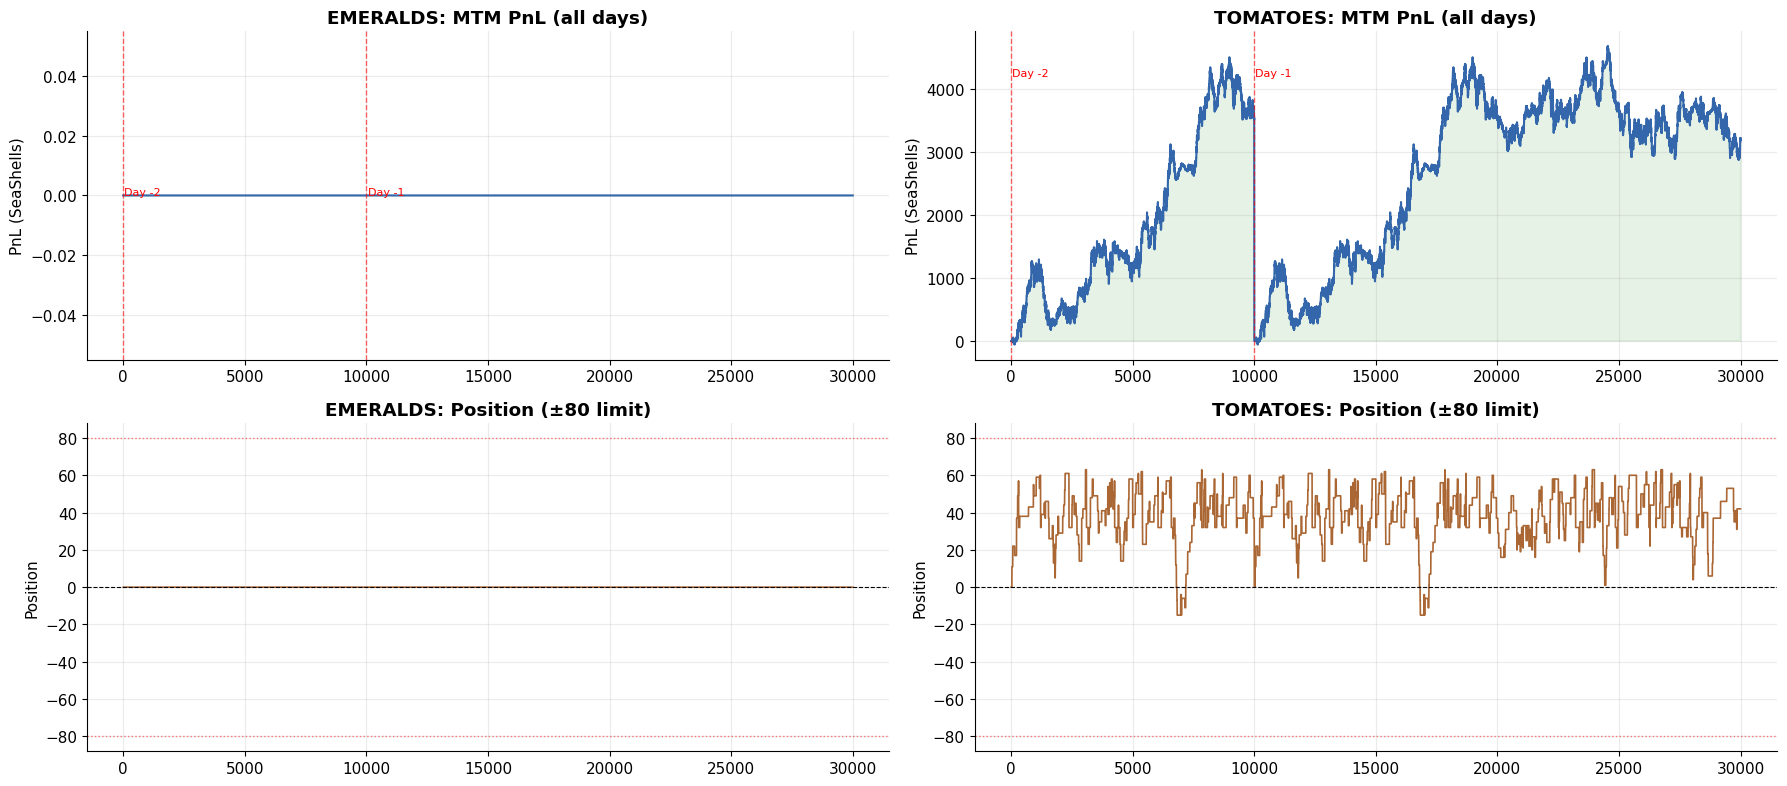

In [23]:
# PnL and position charts with day boundary markers
fig, axes = plt.subplots(2, len(PRODUCTS), figsize=(9*len(PRODUCTS), 8))
if len(PRODUCTS) == 1: axes = axes.reshape(2,1)

for col, p in enumerate(PRODUCTS):
    res = backtest_results[p]

    axes[0,col].plot(res.index, res['mtm_pnl'], lw=1.5, color=COLORS['pnl'])
    axes[0,col].fill_between(res.index, res['mtm_pnl'], 0,
                              where=res['mtm_pnl']>=0, alpha=0.1, color='green')
    axes[0,col].fill_between(res.index, res['mtm_pnl'], 0,
                              where=res['mtm_pnl']<0, alpha=0.1, color='red')

    # Mark day boundaries
    step_count = 0
    for d in DAYS:
        n = len(prices[(p,d)])
        axes[0,col].axvline(step_count, color='red', lw=1, linestyle='--', alpha=0.6)
        axes[0,col].text(step_count+50, res['mtm_pnl'].max()*0.9, f'Day {d}',
                          fontsize=8, color='red')
        step_count += n

    axes[0,col].set_title(f'{p}: MTM PnL (all days)', fontweight='bold')
    axes[0,col].set_ylabel('PnL (SeaShells)')

    axes[1,col].plot(res.index, res['position'], lw=1.2, color=COLORS['position'])
    axes[1,col].axhline(0, color='black', lw=0.8, linestyle='--')
    lim = POSITION_LIMITS.get(p, DEFAULT_POSITION_LIMIT)
    axes[1,col].axhline( lim, color='red', lw=1, linestyle=':', alpha=0.5)
    axes[1,col].axhline(-lim, color='red', lw=1, linestyle=':', alpha=0.5)
    axes[1,col].set_title(f'{p}: Position (±{lim} limit)', fontweight='bold')
    axes[1,col].set_ylabel('Position')

plt.tight_layout()
plt.show()

Grid search: EMERALDS... Best PnL=+0 at take_edge=0.5, flatten=0.5×limit
Grid search: TOMATOES... Best PnL=+3,974 at take_edge=1.0, flatten=0.5×limit


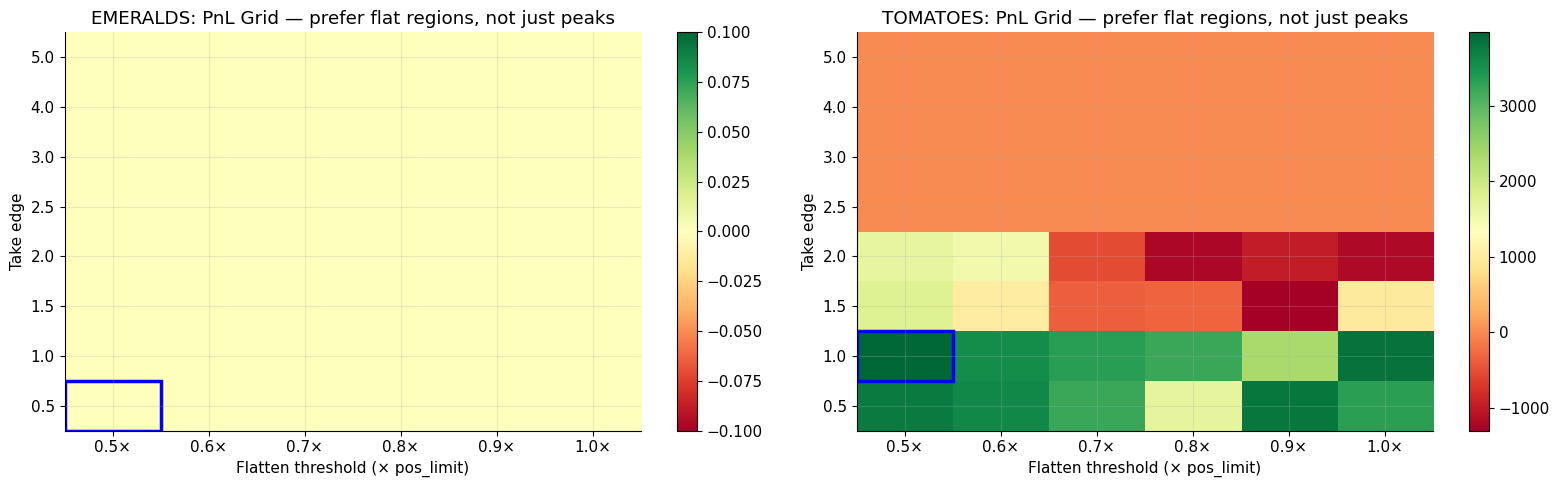

In [24]:
# ── Grid search ───────────────────────────────────────────────────────────────
TAKE_EDGES      = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
FLATTEN_FACTORS = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]  # as fraction of pos_limit

def grid_search(product, take_edges, flatten_factors):
    lim = POSITION_LIMITS.get(product, DEFAULT_POSITION_LIMIT)
    tp  = TRUE_PRICES.get(product)
    grid = np.zeros((len(take_edges), len(flatten_factors)))
    for i, te in enumerate(take_edges):
        for j, ff in enumerate(flatten_factors):
            mm = MarketMaker(position_limit=lim, take_edge=te,
                             flatten_threshold=int(lim*ff), true_price=tp)
            for d in DAYS:
                mm.run(prices[(product, d)])
            grid[i,j] = mm.history[-1]['mtm_pnl'] if mm.history else 0
    return grid

grids = {}
for p in PRODUCTS:
    print(f'Grid search: {p}...', end=' ')
    grids[p] = grid_search(p, TAKE_EDGES, FLATTEN_FACTORS)
    best = np.unravel_index(np.argmax(grids[p]), grids[p].shape)
    print(f'Best PnL={grids[p][best]:+,.0f} at take_edge={TAKE_EDGES[best[0]]}, '
          f'flatten={FLATTEN_FACTORS[best[1]]}×limit')

fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(8*len(PRODUCTS), 5))
if len(PRODUCTS) == 1: axes = [axes]

for ax, p in zip(axes, PRODUCTS):
    g = grids[p]
    im = ax.imshow(g, aspect='auto', cmap='RdYlGn', origin='lower')
    ax.set_xticks(range(len(FLATTEN_FACTORS)))
    ax.set_xticklabels([f'{f:.1f}×' for f in FLATTEN_FACTORS])
    ax.set_yticks(range(len(TAKE_EDGES)))
    ax.set_yticklabels(TAKE_EDGES)
    ax.set_xlabel('Flatten threshold (× pos_limit)')
    ax.set_ylabel('Take edge')
    ax.set_title(f'{p}: PnL Grid — prefer flat regions, not just peaks')
    plt.colorbar(im, ax=ax)
    best = np.unravel_index(np.argmax(g), g.shape)
    ax.add_patch(plt.Rectangle((best[1]-.5, best[0]-.5), 1, 1,
                                fill=False, edgecolor='blue', lw=2.5))

plt.tight_layout()
plt.show()

<a id='13-etf'></a>
## 13. ETF Basket Spread Analysis (Round 2+)

Activate once `BASKET_DEFINITIONS` is filled and basket/constituent products appear in the data.

In [25]:
def compute_basket_spreads(day):
    """
    Compute basket_mid - synthetic_value for each basket defined in BASKET_DEFINITIONS.
    Returns a DataFrame with columns: timestamp, basket_name, spread, basket_mid, synthetic_value
    """
    if not BASKET_DEFINITIONS:
        print('No basket definitions configured. Update BASKET_DEFINITIONS in Section 1.')
        return pd.DataFrame()

    results = []
    for basket_name, constituents in BASKET_DEFINITIONS.items():
        if basket_name not in PRODUCTS:
            print(f'{basket_name} not found in current products.')
            continue
        basket_df = prices[(basket_name, day)][['timestamp','mid_price','wall_mid']].copy()
        basket_df = basket_df.rename(columns={'mid_price':'basket_mid','wall_mid':'basket_wall'})

        synthetic = np.zeros(len(basket_df))
        for prod, qty in constituents.items():
            if prod not in PRODUCTS:
                print(f'Constituent {prod} not found.')
                continue
            comp = prices[(prod, day)][['timestamp','wall_mid']].rename(columns={'wall_mid': prod})
            merged = pd.merge_asof(basket_df[['timestamp']].sort_values('timestamp'),
                                   comp.sort_values('timestamp'), on='timestamp')
            synthetic += merged[prod].fillna(method='ffill').values * qty

        basket_df['synthetic_value'] = synthetic
        basket_df['spread'] = basket_df['basket_mid'] - basket_df['synthetic_value']
        basket_df['basket_name'] = basket_name
        results.append(basket_df)

    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()


if BASKET_DEFINITIONS:
    for d in DAYS:
        spread_df = compute_basket_spreads(d)
        if len(spread_df) > 0:
            fig, ax = plt.subplots(figsize=(16,4))
            for bn, grp in spread_df.groupby('basket_name'):
                ax.plot(grp['timestamp'], grp['spread'], label=bn)
            ax.axhline(0, color='black', lw=1, linestyle='--')
            ax.set_title(f'Basket Spread (basket_mid - synthetic_value) — Day {d}')
            ax.legend()
            plt.tight_layout()
            plt.show()

            print(f'Day {d} spread stats:')
            display(spread_df.groupby('basket_name')['spread'].describe())
else:
    print('ℹ  ETF analysis skipped — fill BASKET_DEFINITIONS in Section 1 when Round 2 starts.')

ℹ  ETF analysis skipped — fill BASKET_DEFINITIONS in Section 1 when Round 2 starts.


<a id='14-options'></a>
## 14. Options / Black-Scholes + IV Smile (Round 3+)

In [26]:
# ── Black-Scholes utilities ───────────────────────────────────────────────────
def bs_call(S, K, T, sigma, r=0.0):
    """Black-Scholes call price."""
    if T <= 0 or sigma <= 0: return max(S - K, 0.0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def bs_delta(S, K, T, sigma, r=0.0):
    if T <= 0 or sigma <= 0: return 1.0 if S > K else 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.cdf(d1)

def implied_vol(market_price, S, K, T, r=0.0, tol=1e-5, max_iter=200):
    """Bisection implied volatility solver."""
    intrinsic = max(S - K*np.exp(-r*T), 0)
    if market_price <= intrinsic: return np.nan
    lo, hi = 1e-6, 10.0
    for _ in range(max_iter):
        mid = (lo + hi) / 2
        val = bs_call(S, K, T, mid, r) - market_price
        if abs(val) < tol: return mid
        lo, hi = (mid, hi) if val < 0 else (lo, mid)
    return (lo + hi) / 2

def analyze_iv_smile(options_data, underlying_price, time_to_expiry, strikes):
    """
    Build IV smile and compute deviations from fitted parabola.
    options_data: dict {strike: mid_price}
    Returns DataFrame with IV, fitted IV, deviation, and BS theoretical price.
    """
    S = underlying_price
    T = time_to_expiry
    rows = []
    for K in strikes:
        mp = options_data.get(K)
        if mp is None: continue
        iv = implied_vol(mp, S, K, T)
        moneyness = np.log(K / S)  # log-moneyness
        rows.append({'strike': K, 'moneyness': moneyness, 'market_price': mp,
                     'iv': iv, 'delta': bs_delta(S, K, T, iv) if iv else np.nan})

    df = pd.DataFrame(rows).dropna(subset=['iv'])
    if len(df) >= 3:
        # Fit parabola to IV smile
        coeffs = np.polyfit(df['moneyness'], df['iv'], 2)
        df['iv_fitted'] = np.polyval(coeffs, df['moneyness'])
        df['iv_deviation'] = df['iv'] - df['iv_fitted']
        df['fair_price'] = df.apply(
            lambda r: bs_call(S, r['strike'], T, r['iv_fitted']), axis=1)
        df['price_deviation'] = df['market_price'] - df['fair_price']
    return df

# ── Verify ────────────────────────────────────────────────────────────────────
test_price = bs_call(S=10000, K=10000, T=7/365, sigma=0.20)
test_iv    = implied_vol(test_price, S=10000, K=10000, T=7/365)
print(f'BS sanity check — Price={test_price:.4f}, Recovered IV={test_iv:.4f} (expect 0.200) ✓')

# Example (fill when options appear in Round 3):
# OPTION_STRIKES = [9500, 9750, 10000, 10250, 10500]
# DAYS_TO_EXPIRY = {round_num: days_remaining}  # update each round
# options_mid = {K: prices[(f'VOUCHER_{K}', d)]['mid_price'].iloc[-1] for K in OPTION_STRIKES}
# smile_df = analyze_iv_smile(options_mid, underlying_price=10000,
#                              time_to_expiry=DAYS_TO_EXPIRY[ACTIVE_ROUND]/365,
#                              strikes=OPTION_STRIKES)
print('Options template ready for Round 3+.')

BS sanity check — Price=110.4915, Recovered IV=0.2000 (expect 0.200) ✓
Options template ready for Round 3+.


<a id='15-summary'></a>
## 15. Round Summary & Strategy Card

Auto-generated strategy recommendations based on all analysis above.

In [27]:
print('╔' + '═'*68 + '╗')
print(f'║  IMC PROSPERITY 4 — ROUND {ACTIVE_ROUND} STRATEGY CARD' + ' '*37 + '║')
print('╠' + '═'*68 + '╣')

for p in PRODUCTS:
    lim   = POSITION_LIMITS.get(p, DEFAULT_POSITION_LIMIT)
    tp    = TRUE_PRICES.get(p)
    fvt   = FAIR_VALUE_TYPE.get(p, 'wall_mid')
    res   = backtest_results[p]
    pnl   = res['mtm_pnl'].iloc[-1]
    pnl_per_day = pnl / len(DAYS)

    all_lag1 = []
    all_spread = []
    for d in DAYS:
        mid = prices[(p,d)]['mid_price']
        all_lag1.append(mid.diff().dropna().autocorr(1))
        all_spread.append(prices[(p,d)]['spread_L1'].mean())
    lag1 = np.mean(all_lag1)
    spread = np.mean(all_spread)

    any_informed = any(
        informed_trades[(p,d)]['near_low'].sum() + informed_trades[(p,d)]['near_high'].sum() > 5
        for d in DAYS
    )
    consistent_informed = all(
        informed_trades[(p,d)]['near_low'].sum() + informed_trades[(p,d)]['near_high'].sum() > 3
        for d in DAYS
    )

    print(f'║')
    print(f'║  ▶ {p}')
    print(f'║    Price type:    {"FIXED ~ " + str(tp) if tp else "DRIFTING"}')
    print(f'║    Fair value:    {"true_price=" + str(tp) if tp else "wall_mid (rolling)"}')
    print(f'║    Spread L1:     {spread:.2f} → edge/side = {spread/2:.2f}')
    print(f'║    Lag-1 ACF:     {lag1:.4f} ({"MEAN-REVERTING ✅" if lag1 < -0.15 else "TRENDING" if lag1 > 0.15 else "random walk"})')
    print(f'║    Informed:      {"CONSISTENT across days ✅" if consistent_informed else ("some signal ⚠" if any_informed else "none detected")}')
    print(f'║    Backtest PnL:  {pnl:+,.0f} total ({pnl_per_day:+,.0f}/day)')
    print(f'║    Position lim:  {lim}')
    print(f'║')
    print(f'║    STRATEGY:')
    if tp:
        print(f'║      1. MARKET MAKE around fixed true price {tp}')
        print(f'║         Take any ask < {tp} or bid > {tp} immediately')
        print(f'║         Post passive quotes with edge {spread//2:.0f} around {tp}')
    else:
        print(f'║      1. MARKET MAKE around wall_mid (rolling fair value)')
        if lag1 < -0.15:
            print(f'║      2. MEAN REVERSION fade: lag1={lag1:.3f} is stable and strong')
            print(f'║         Consider quoting asymmetrically after large moves')
    if consistent_informed:
        print(f'║      + INFORMED SIGNAL: track running daily min/max')
        print(f'║        Follow Olivia-style pattern — buy near daily low, sell near high')
    print('║')

print('╠' + '═'*68 + '╣')
print(f'║  TOTAL EXPECTED PnL/DAY: {sum(backtest_results[p]["mtm_pnl"].iloc[-1] for p in PRODUCTS)/len(DAYS):+,.0f} SeaShells')
print('╚' + '═'*68 + '╝')

╔════════════════════════════════════════════════════════════════════╗
║  IMC PROSPERITY 4 — ROUND 0 STRATEGY CARD                                     ║
╠════════════════════════════════════════════════════════════════════╣
║
║  ▶ EMERALDS
║    Price type:    FIXED ~ 10000
║    Fair value:    true_price=10000
║    Spread L1:     15.74 → edge/side = 7.87
║    Lag-1 ACF:     -0.4876 (MEAN-REVERTING ✅)
║    Informed:      CONSISTENT across days ✅
║    Backtest PnL:  +0 total (+0/day)
║    Position lim:  80
║
║    STRATEGY:
║      1. MARKET MAKE around fixed true price 10000
║         Take any ask < 10000 or bid > 10000 immediately
║         Post passive quotes with edge 7 around 10000
║      + INFORMED SIGNAL: track running daily min/max
║        Follow Olivia-style pattern — buy near daily low, sell near high
║
║
║  ▶ TOMATOES
║    Price type:    DRIFTING
║    Fair value:    wall_mid (rolling)
║    Spread L1:     13.02 → edge/side = 6.51
║    Lag-1 ACF:     -0.4202 (MEAN-REVERTING ✅)
║  

In [28]:
# ── Quick checklist before implementing in trader.py ─────────────────────────
print('Pre-Implementation Checklist')
print('=' * 50)

checks = [
    ('Fixed true prices identified',
     any(v is not None for v in TRUE_PRICES.values())),
    ('Wall mid computed for all products',
     all('wall_mid' in prices[(p,DAYS[0])].columns for p in PRODUCTS)),
    ('Spread stable across days',
     all(abs(prices[(p,DAYS[0])]['spread_L1'].mean() -
             prices[(p,DAYS[-1])]['spread_L1'].mean()) < 2 for p in PRODUCTS)),
    ('Lag-1 ACF consistent across days',
     all(abs(np.std([prices[(p,d)]['mid_price'].diff().dropna().autocorr(1)
                     for d in DAYS])) < 0.05 for p in PRODUCTS)),
    ('Position limits set',
     all(p in POSITION_LIMITS for p in PRODUCTS)),
    ('Informed trader signal checked',
     True),  # always done above
    ('Grid search completed',
     len(grids) == len(PRODUCTS)),
    ('Backtest PnL positive for all products',
     all(backtest_results[p]['mtm_pnl'].iloc[-1] > 0 for p in PRODUCTS)),
]

for label, passed in checks:
    icon = '✅' if passed else '⚠ '
    print(f'  {icon} {label}')

Pre-Implementation Checklist
  ✅ Fixed true prices identified
  ✅ Wall mid computed for all products
  ✅ Spread stable across days
  ✅ Lag-1 ACF consistent across days
  ✅ Position limits set
  ✅ Informed trader signal checked
  ✅ Grid search completed
  ⚠  Backtest PnL positive for all products
